**Chapter 16 – Natural Language Processing with RNNs and Attention**

_This notebook contains all the sample code and solutions to the exercises in chapter 16._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/16_nlp_with_rnns_and_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/16_nlp_with_rnns_and_attention.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

**Warning**: the latest TensorFlow versions are based on Keras 3. For previous chapters, it wasn't too hard to update the code to support Keras 3, but unfortunately it's much harder for this chapter: for example, stateful RNNs work very differently, ragged tensors are no longer supported, TensorFlow Hub models are no longer supported, and more. So for this chapter I've had to revert to Keras 2. To do that, I set the `TF_USE_LEGACY_KERAS` environment variable to `"1"` and import the `tf_keras` package. This ensures that `tf.keras` points to `tf_keras`, which is Keras 2.*.

In [2]:
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    import os
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

And TensorFlow ≥ 2.8:

In [3]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

I0000 00:00:1780560578.484052     622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780560579.068940     622 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780560580.944660     622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [66]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/nlp` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [68]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "nlp"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

This chapter can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

In [6]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

No GPU was detected. Neural nets can be very slow without a GPU.


W0000 00:00:1779781648.449121     499 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Generating Shakespearean Text Using a Character RNN

## Creating the Training Dataset

Let's download the Shakespeare data from Andrej Karpathy's [char-rnn project](https://github.com/karpathy/char-rnn/)

In [1]:
import tensorflow as tf

shakespeare_url = "https://homl.info/shakespeare"  # shortcut URL # obras de Shakespeare en texto plano
filepath = tf.keras.utils.get_file("shakespeare.txt", shakespeare_url) # lo gusrda en caché. descarga el contenido de esta URL y guárdalo localmente con este nombre
with open(filepath) as f: # abre el archivo
    shakespeare_text = f.read() # lo lee

I0000 00:00:1780565849.063637    2570 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780565849.186791    2570 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780565851.026831    2570 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [6]:
# extra code – shows a short text sample
print(shakespeare_text[:80]) # imprime los primeros 80 caracteres

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.


In [7]:
# extra code – shows all 39 distinct characters (after converting to lower case)
# qué caracteres distintos existen en el texto
# lower -> minúsculas
# set -> elimina carcateres duplicados
# sorted -> ordena alfabéticamente
# "".join() ->concatena todo en unúnico string, usa como separador "
"".join(sorted(set(shakespeare_text.lower())))

"\n !$&',-.3:;?abcdefghijklmnopqrstuvwxyz"

In [8]:
# Convierte texto en números. redes neuronales no entienden texto


text_vec_layer = tf.keras.layers.TextVectorization(split="character",
                                                   standardize="lower") # Crea una capa de:tokenización/vectorización de texto 
# split="character" -> tokeniza carácter a carácter
# standardize="lower"-> convierte todo  a minúsculas
text_vec_layer.adapt([shakespeare_text]) # la capa arende el vocabulario (.adapt) -> crea un diccionario token <-> número entero
# aprende [shakespeare_text] que es una lista con único documento gigante (podría añadir más documetos). Lista porque TextVectorization espera batch de textos

encoded = text_vec_layer([shakespeare_text])[0] # vectorización real

# text_vec_layer([]) convuerte caracteres en ids de números enteros

# TextVectorization devuelve 1 batch (lista) con 1 sólo elemento -> shape(1, sequence length) -> hay una dimensión de más
# al pedirle el primer elemento [0] la shape pasa a (sequence length) -> hemos quitado la dimensión batch

TextVectorization reserva automáticamente:


token	significado

0	padding

1	unknown/OOV

Antes de limpiar

| char | id |
| ---- | -- |
| PAD  | 0  |
| UNK  | 1  |
| a    | 2  |
| b    | 3  |


Después de limpiar

| char | id |
| ---- | -- |
| a    | 0  |
| b    | 1  |
| c    | 2  |


In [9]:
# Limpiamos la codificación que creó TextVectorization

encoded -= 2  # drop tokens 0 (pad) and 1 (unknown), which we will not use. reindexa los caracteres reales desde 0
n_tokens = text_vec_layer.vocabulary_size() - 2  # number of distinct chars = 39. Quita de los tokens los correspondientes a PAD y UNK que hemos quitados
dataset_size = len(encoded)  # total number of chars = 1,115,394 cuántos caracteres hay en total



# Conceptualmente Ha hecho:

# new id=old id−2

# Entonces para invertirlo:

# old id=new id+2 -> necesitará esto para convertir de ids a caracteres



In [10]:
n_tokens

39

In [11]:
dataset_size

1115394

In [12]:
# Convertir esta secuencia tan larga  en un conjunto de datos de ventanas que podamos usar para entrenar una RNR secuencia a secuencia
# Esta función crea un dataset para entrenar un modelo que predice el siguiente carácter en cada posición.
# agrupará 32 ventanas
def to_dataset(sequence, length, shuffle=False, seed=None, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices(sequence) # convierte una lista en dataset elemento a elemento
    ds = ds.window(length + 1, shift=1, drop_remainder=True) # Crea ventanas deslizantes de tamaño length + 1
     # se puede hacer en un único paso:
     # ds = tf.data.Dataset.from_tensor_slices(sequence).window(length + 1,shift=1,drop_remainder=True)
     # Ponemos length + 1 porque porque queremos que x tenga tamaño length, pero luego pondremos que x = tomod menos la última [:, :-1] esto quita un elemento, quedando en length
    
    ds = ds.flat_map(lambda window_ds: window_ds.batch(length + 1)) # Después .window, cada ventana es un dataset, no un tensor
    # esto convierte cada ventana en un tensor. mantenemos lenght +1 para seguir con la misma estructura
    
    if shuffle:
        ds = ds.shuffle(100_000, seed=seed) # hace shuffle con un buffer de 100000 elementos (ventanas)
    ds = ds.batch(batch_size, drop_remainder=True) # agrupa en 32 ventanas -> batch real de entrenamiento. Ahora (32 , length + 1) Ojo! añadimos drop_remainder < geron no(
    return ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1)
    #Todos los batches
    # x= tod menos el último elemento
    #Y = todo menos el primer elemento

In [13]:
# extra code – a simple example using to_dataset()
# There's just one sample in this dataset: the input represents "to b" and the
# output represents "o be"
list(to_dataset(text_vec_layer(["To be"])[0], length=4))

# text_vec_layer(["To be"]) -> Convierte el texto en ids
# [0] -> Quita dimensión batch
# to_dataset(..., length=4) ->  X tendrá longitud 4 entonces la ventana será de 5


[]

shape=(1, 4) - 1 secuencia , 4 tokens 

en estructura

[
 (X_tensor, y_tensor)
]

In [14]:
# Crear conjunto de entrenamiento (90%), validación (5%) y prueba (5%)

length = 100 # cada secuencia de entrada tendrá 100 caracteres -> cada venta interna tendrá realmente 101
tf.random.set_seed(42)
train_set = to_dataset(encoded[:1_000_000], length=length, shuffle=True,
                       seed=42)
valid_set = to_dataset(encoded[1_000_000:1_060_000], length=length)
test_set = to_dataset(encoded[1_060_000:], length=length)

## Building and Training the Char-RNN Model

**Warning**: the following code may one or two hours to run, depending on your GPU. Without a GPU, it may take over 24 hours. If you don't want to wait, just skip the next two code cells and run the code below to download a pretrained model.

**Note**: the `GRU` class will only use cuDNN acceleration (assuming you have a GPU) when using the default values for the following arguments: `activation`, `recurrent_activation`, `recurrent_dropout`, `unroll`, `use_bias` and `reset_after`.

In [17]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=n_tokens, output_dim=16),# input_dim=número de tokens posibles, salida cada carácter vector 16 dimensiones
   
    # pasamos de (batch,100) a (batch,100,16)
    tf.keras.layers.GRU(128, return_sequences=True), # Pasamos de (batch,100,16) a (batch,100,128)
    # Porcesa 100 tiemsteps y cada uno procesa un tamaño de 128
    # muy importante return_sequences=True -> queremos prediciión cada timestep no sólo al final
    tf.keras.layers.Dense(n_tokens, activation="softmax") # convierte 128 features en 39 probabilidades, que suman 1 (softmax): (batch,100,39)
])

# comprobación chatgpt
for X_batch, y_batch in train_set.take(1):
    print(X_batch.shape, y_batch.shape)
    print(tf.reduce_min(X_batch).numpy(), tf.reduce_max(X_batch).numpy())
    print(tf.reduce_min(y_batch).numpy(), tf.reduce_max(y_batch).numpy())

    y_proba = model(X_batch)
    print(tf.reduce_any(tf.math.is_nan(y_proba)).numpy())
    print(tf.reduce_min(y_proba).numpy(), tf.reduce_max(y_proba).numpy())

    loss = tf.keras.losses.SparseCategoricalCrossentropy()(y_batch, y_proba)
    print(loss.numpy())



model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"]) # loss "categorical" porque clasifica cuá es el siguiente carcater "sparse" porque targets son enteros, no one hot vectors
                                    # nadam -> muy usado en NLP
model_ckpt = tf.keras.callbacks.ModelCheckpoint(
    "my_shakespeare_model.keras", monitor="val_accuracy", save_best_only=True)
# checkpoint para guardar el mejor modelo según val accuracy -> se llamará my_shakespeare_model. Hay que indicar el tipo de archivo : .keras
history = model.fit(train_set, validation_data=valid_set, epochs=10,
                    callbacks=[model_ckpt]) # entrena el modelo

2026-05-25 14:45:22.499504: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 92536 of 100000
2026-05-25 14:45:23.281652: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


(32, 100) (32, 100)
0 35
0 35
False
0.024937376 0.026348442
3.6632833
Epoch 1/10


2026-05-25 14:45:24.196349: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91501
2026-05-25 14:45:24.344811: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-25 14:45:35.244823: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 86421 of 100000
2026-05-25 14:45:36.765401: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


     11/Unknown 13s 29ms/step - accuracy: 0.1062 - loss: 3.6377

KeyboardInterrupt: 

Importante!!!!

encoded solo existió durante el entrenamiento

hice:

encoded = text_vec_layer([shakespeare_text])[0]

y eso creó una versión ya vectorizada del corpus Shakespeare.

Pero el modelo entrenado NO recuerda cómo convertir texto → tokens. Sólo aprendió ids numéricos → siguiente id

Hay que "envolver" este modelo con una capa de procesamiento, restándole a X 2 índices. 
No restamos a Y porque ya no hay Y. No estamos en entrenamiento.

In [15]:
# Envolvemos modelo con capa de preprocesamiento
shakespeare_model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Lambda(lambda X: X - 2),  # no <PAD> or <UNK> tokens
    model
])

NameError: name 'model' is not defined

If you don't want to wait for training to complete, I've pretrained a model for you. The following code will download it. Uncomment the last line if you want to use it instead of the model trained above.

In [21]:
import os
os.path.exists("my_shakespeare_model.keras")

True

In [22]:
# Cargo mi modelo guardado my_shakespeare_model.keras
my_model = tf.keras.models.load_model("my_shakespeare_model.keras")

# envuelvo mi modelo con preprocesamiento
shakespeare_model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Lambda(lambda X: X - 2),
    my_model
])

In [23]:
# extra code – downloads a pretrained model. ËSTE es el modelo de geron. que no es compatible, por eso cargo el mío antes
url = "https://github.com/ageron/data/raw/main/shakespeare_model.tgz"
path = tf.keras.utils.get_file("shakespeare_model.tgz", url, extract=True)
if "_extracted" in path:
    model_path = Path(path) / "shakespeare_model"
else:
    model_path = Path(path).with_name("shakespeare_model")

#shakespeare_model = tf.keras.models.load_model(model_path)

In [24]:
# Hacemos predicción

# Primero la probabilidad
# la salida del modelo es shape (1,sequence_length,39) 
y_proba = shakespeare_model.predict(
    tf.constant(["To be or not to b"]))[0, -1] # primer batch (sólo hay uno) , último timestep


y_pred = tf.argmax(y_proba)  # choose the most probable character ID. Elige el índice con mayor probabilidad
text_vec_layer.get_vocabulary()[y_pred + 2] # convertir el id predicho en caracter real, corrigiendo el id dezplazado (+2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


np.str_('e')

## Generating Fake Shakespearean Text

tf.argmax(y_proba) -> elige siempre el carácter más probable

Problema-> Texto repetitivo, aburrido y determinista

tf.random.categorical() -> muestrea según probabilidades


In [25]:
log_probas = tf.math.log([[0.5, 0.4, 0.1]])  # probas = 50%, 40%, and 10% 
# Porque categorical() espera: logits o log-probabilidades
tf.random.set_seed(42)
tf.random.categorical(log_probas, num_samples=8)  # draw 8 samples haz 8 sorteos siguiendo esa distribución

<tf.Tensor: shape=(1, 8), dtype=int64, numpy=array([[0, 0, 1, 1, 1, 0, 0, 0]])>

0 aparece más

1 bastante

2 poco

Importante porque respeta las probabilidades


## Baremo de Temperature

| temperature | efecto |
|---|---|
| 0 | casi determinista |
| 0.1–0.3 | muy conservador |
| 0.5–0.8 | equilibrado |
| 1.0 | distribución original |
| 1.2–1.8 | creativo/caótico |
| >2 | normalmente basura |

In [26]:
# Esta función -> dado un texto, genera el siguiente carácter
# Temperature -> controla creatividad vs conservadurismo
# Temperatura baja  (0.2) -> Modelo más conservador. Probabilidades grandes se vuelven más dominantes -> repetitivo, poco creativo, coherente
# Temperaturs alta (2) -> Más creativo, aleatorio, más lco
def next_char(text, temperature=1):
    y_proba = shakespeare_model.predict(tf.constant([text]))[0, -1:] # devuelve probabilidades del siguiente carácter
    
    # en tu Keras actual, predict() no acepta una lista Python de strings -> tf.constant([text])
    rescaled_logits = tf.math.log(y_proba) / temperature
    char_id = tf.random.categorical(rescaled_logits, num_samples=1)[0, 0] # Muestreo. Se sortea el siguiente carácter
    return text_vec_layer.get_vocabulary()[char_id + 2] # convierte ID en carácter (modelo tranbaja con IDs desplazados)

In [27]:
# el bucle completo de generación de texto. repite next_char n_chars veces

def extend_text(text, n_chars=50, temperature=1):
    for _ in range(n_chars):
        text += next_char(text, temperature)
    return text

In [28]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

In [29]:
print(extend_text("To be or not to be", temperature=0.01))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

In [30]:
print(extend_text("To be or not to be", temperature=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

In [31]:
print(extend_text("To be or not to be", temperature=100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

## Stateful RNN / RNR con estado

In [16]:
def to_dataset_for_stateful_rnn(sequence, length):
    ds = tf.data.Dataset.from_tensor_slices(sequence)
    ds = ds.window(length + 1, shift=length, drop_remainder=True) # ya no hay un deslizamiento de 1 sino del bloque completo
    # Ahora ventanas consecutivas sonm solapamiento
    # Todavía son datasets anidados no tensores
    ds = ds.flat_map(lambda window: window.batch(length + 1)).batch(1) # Cooge  101 elementos de cada ventana y conviértelos en tensor
    # + 1 para coger las y
    # Como ahora es tensor la estructura es (batch, sequence) -> seleccionamos x ( todos los batches, toda la secuencia menos el útlimo carcater) e y (todos los batches, secuencia  a partir del segundo caracter) 
    return ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1) # obtener tensores de x e Preparo el segundo lote

stateful_train_set = to_dataset_for_stateful_rnn(encoded[:1_000_000], length)
stateful_valid_set = to_dataset_for_stateful_rnn(encoded[1_000_000:1_060_000],
                                                 length)
stateful_test_set = to_dataset_for_stateful_rnn(encoded[1_060_000:], length)

In [17]:
# extra code – simple example using to_dataset_for_stateful_rnn()
list(to_dataset_for_stateful_rnn(tf.range(10), 3))

[(<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[0, 1, 2]], dtype=int32)>,
  <tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[1, 2, 3]], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[3, 4, 5]], dtype=int32)>,
  <tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[4, 5, 6]], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[6, 7, 8]], dtype=int32)>,
  <tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[7, 8, 9]], dtype=int32)>)]

If you'd like to have more than one window per batch, you can use the `to_batched_dataset_for_stateful_rnn()` function instead of `to_dataset_for_stateful_rnn()`:

In [18]:
# extra code – shows one way to prepare a batched dataset for a stateful RNN

import numpy as np

def to_non_overlapping_windows(sequence, length):
    ds = tf.data.Dataset.from_tensor_slices(sequence)
    ds = ds.window(length + 1, shift=length, drop_remainder=True)
    return ds.flat_map(lambda window: window.batch(length + 1))

def to_batched_dataset_for_stateful_rnn(sequence, length, batch_size=32):
    parts = np.array_split(sequence, batch_size)
    datasets = tuple(to_non_overlapping_windows(part, length) for part in parts)
    ds = tf.data.Dataset.zip(datasets).map(lambda *windows: tf.stack(windows))
    return ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1)

list(to_batched_dataset_for_stateful_rnn(tf.range(20), length=3, batch_size=2))

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 0,  1,  2],
         [10, 11, 12]], dtype=int32)>,
  <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 1,  2,  3],
         [11, 12, 13]], dtype=int32)>),
 (<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 3,  4,  5],
         [13, 14, 15]], dtype=int32)>,
  <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 4,  5,  6],
         [14, 15, 16]], dtype=int32)>),
 (<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 6,  7,  8],
         [16, 17, 18]], dtype=int32)>,
  <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[ 7,  8,  9],
         [17, 18, 19]], dtype=int32)>)]

In [19]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
model = tf.keras.Sequential([
    tf.keras.layers.Input(batch_shape=(1, None), dtype=tf.int32), # batch_shape=[1, None] -> batch size FIJO, longitud secuencia variable
    tf.keras.layers.Embedding(input_dim=n_tokens, output_dim=16),
     
    tf.keras.layers.GRU(128, return_sequences=True, stateful=True),
    # stateful=True -> hace que el estado del batch 1 pase al batch 2. No empieza desde cero
    # Shape salida GRU: (1,sequence_length,128)
    tf.keras.layers.Dense(n_tokens, activation="softmax") # convierte 128 features en 39 probabilidades (n_tokens)
    # shape salida: (1,sequence_length,39)
])

In [20]:
# Al final de cada repetición (epoch) hay que restaurar los estados antes de volver al principio del texto

class ResetStatesCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        for layer in self.model.layers:
            if hasattr(layer, "reset_states"):
                layer.reset_states()

In [21]:
# sirve para guardar automáticamente el mejor modelo durante el entrenamiento.en una directorio diferente
# extra code – use a different directory to save the checkpoints
model_ckpt = tf.keras.callbacks.ModelCheckpoint(
    "my_stateful_shakespeare_model.keras",
    monitor="val_accuracy",
    save_best_only=True)

**Warning**: the following cell will take a while to run (possibly an hour if you are not using a GPU).

In [22]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [24]:
# l flujo completo típico de entrenamiento en Keras:

model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"], run_eagerly=True) # cómo aprende, cómo mide erroes qué optimizador usa
history = model.fit(stateful_train_set, validation_data=stateful_valid_set,
                    epochs=10, callbacks=[ResetStatesCallback(), model_ckpt])

NameError: name 'model_ckpt' is not defined

**Extra Material: converting the stateful RNN to a stateless RNN and using it**

To use the model with different batch sizes, we need to create a stateless copy:

Entrenaron una RNN stateful, pero para generar texto la convierten en stateless.

¿Por qué? Porque para generar texto no quieres estar obligado a usar siempre batch_size=1 fijo, ni arrastrar estados raros entre llamadas.

Idea

modelo stateful entrenado

        ↓
        
copiamos sus pesos

        ↓
        
modelo stateless equivalente

        ↓
        
lo usamos cómodamente para generar texto

In [25]:
# Creamos un modelo sin estado

stateless_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=n_tokens, output_dim=16), # no ponemos capa input 
    tf.keras.layers.GRU(128, return_sequences=True),
    tf.keras.layers.Dense(n_tokens, activation="softmax")
])

To set the weights, we first need to build the model (so the weights get created):

In [26]:
stateless_model.build(tf.TensorShape([None, None])) #“prepárate para recibir tensores de shape: (batch_size, sequence_length)”

In [27]:
stateless_model.set_weights(model.get_weights()) #copia lo aprendido por el modelo stateful al nuevo modelo stateless

In [28]:
# Envolvemos el modeo sin estado con una capa de procesamiento
shakespeare_model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Lambda(lambda X: X - 2),  # no <PAD> or <UNK> tokens
    stateless_model
])

In [29]:
tf.random.set_seed(42)

print(extend_text("to be or not to be", temperature=0.01))

NameError: name 'extend_text' is not defined

# Sentiment Analysis

Vamos a descargar el conjunto de datos de imdb.
Este dataset de IMDB tiene reseñas de películas con etiqueta:
0= negativa
1= poaitiva

vamos a separar el dataset en:
train[:90%]  → 90% entrenamiento

train[90%:]  → 10% validación

test         → prueba final -> ya viene definido en el propio dataset




In [23]:

import tensorflow_datasets as tfds

raw_train_set, raw_valid_set, raw_test_set = tfds.load(
    name="imdb_reviews",
    split=["train[:90%]", "train[90%:]", "test"],
    as_supervised=True # s_supervised=True, cada ejemplo viene como: (texto, etiqueta) (b"This movie was great...", 1)
)
tf.random.set_seed(42)
train_set = raw_train_set.shuffle(5000, seed=42).batch(32).prefetch(1) # 1) mezcla, agrupa en batches de 32, prepara el mismo batch mientras entrena
valid_set = raw_valid_set.batch(32).prefetch(1) # idem pero sin mezclar
test_set = raw_test_set.batch(32).prefetch(1) # idem pero sin mezclar

In [24]:
# Inspeccionar algunas críticas
for review, label in raw_train_set.take(4):    # coge las primeras 4 reseñas
    print(review.numpy().decode("utf-8")[:200], "...")
    # review.numpy() -> convierte el tensor TensorFlow a un objeto NumPy/Python normal.
    # Peros siguen siendo bytes (por ejemplo b"This movie...")
    # .decode("utf-8") -> Convierte bytes en texto legible . primeros 200 caracteres
    print("Label:", label.numpy())# devuelve 0 (neg) o 1 (posit)

This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting  ...
Label: 0
I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However  ...
Label: 0
Mann photographs the Alberta Rocky Mountains in a superb fashion, and Jimmy Stewart and Walter Brennan give enjoyable performances as they always seem to do. <br /><br />But come on Hollywood - a Moun ...
Label: 0
This is the kind of film for a snowy Sunday afternoon when the rest of the world can go ahead with its own business as you descend into a big arm-chair and mellow for a couple of hours. Wonderful perf ...
Label: 1


I0000 00:00:1780565983.549847    2916 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1780565983.563551    2920 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [25]:
vocab_size = 1000 # Tamaño del vocabulario. Sólo hay quie conservar las 1000 palabrasmás frecuentes
text_vec_layer = tf.keras.layers.TextVectorization(max_tokens=vocab_size) # esta capa limpia texto, tokeniza, crea vocabulario, convierte palabras en enteros
text_vec_layer.adapt(train_set.map(lambda reviews, labels: reviews))
# .adapt -> la capa aprende el vocabulario -> palabras más frecuentes, índices, estadísiticas
# train_set.map(lambda reviews, labels: reviews) # el entrenbamuiento pasa de tener salida (reviews, labels) a sólo reviews porque .adapt() SÓLO LEE TEXTO

**Warning**: the following cell will take a few minutes to run and the model will probably not learn anything because we didn't mask the padding tokens (that's the point of the next section).

In [53]:
embed_size = 128
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer, # Convierte texto → enteros.
    tf.keras.layers.Embedding(vocab_size, embed_size), # cada palabra -> vector de 128 números
    tf.keras.layers.GRU(128), # la GRU procesa la secuencia de palabras.
        # No usamos return_sequences=True porque no quiero salidas en cada palabra sino el sentiemnto final de toda la reseña
    tf.keras.layers.Dense(1, activation="sigmoid") # produce un úmero etre 0 y 1 -> Probabilidad de crítica positiva
])
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
# loss="binary_crossentropy" solo hay dos clases:0 o 1
history = model.fit(train_set, validation_data=valid_set, epochs=2)

Epoch 1/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.5003 - loss: 0.6936 - val_accuracy: 0.5028 - val_loss: 0.6929
Epoch 2/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.5027 - loss: 0.6930 - val_accuracy: 0.5028 - val_loss: 0.6929


Evolución de la shape en el modelo
(32,) batches definidos

 ↓
 
(32, sequence_length) # convertimos los batches en enteros

 ↓
 
(32, sequence_length, 128)# embeeding convertimos las frases convertidas a números en vectores de 128 números2

 ↓
 
(32, 128) Vector resumen de la reseña

 ↓
 
(32, 1) Salida de una probabilidad


¿Por qué hay que vectorizar antes del embedding?

Porque la capa Embedding NO entiende texto.


Solo entiende índices enteros.

## Masking

**Warning**: the following cell will take a while to run (possibly 30 minutes if you are not using a GPU).


Se llama Masking porque literalmente está “tapando” (masking) partes del tensor para que la red las ignore.


In [33]:
# Esto debería mejorar el entrenamiento, sobre todo si hay reseñas de longitudes muy distintas. Masking con Keras

# El masking se realiza en la capa de embedding y luego lo pasa a la capa de GRU
# Embedding crea y envía la máscara
# La GRU es quien realmnete necesita la máscara para decidir
embed_size = 128
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(vocab_size, embed_size, mask_zero=True),
    # mask_zero=True -> Ignora los tokens de relleno, cada entrada puede tener tamaños distinos
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=5)

Epoch 1/5


E0000 00:00:1779781780.099527     499 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


105/704 ━━━━━━━━━━━━━━━━━━━━ 2:20 234ms/step - accuracy: 0.5360 - loss: 0.6890

KeyboardInterrupt: 

Or using manual masking:

In [26]:
# Masking manual
# Se genera el masking por separado y luego se incluye en GRU
tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU
inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)
token_ids = text_vec_layer(inputs)
mask = tf.keras.layers.Lambda(
    lambda X: tf.not_equal(X, 0)
)(token_ids)
Z = tf.keras.layers.Embedding(vocab_size, embed_size)(token_ids)
Z = tf.keras.layers.GRU(128, dropout=0.2)(Z, mask=mask)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(Z)
model = tf.keras.Model(inputs=[inputs], outputs=[outputs])


NameError: name 'embed_size' is not defined

**Warning**: the following cell will take a while to run (possibly 30 minutes if you are not using a GPU).

In [58]:
# extra code – compiles and trains the model, as usual
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=5)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - accuracy: 0.7616 - loss: 0.4783 - val_accuracy: 0.8548 - val_loss: 0.3439
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.8643 - loss: 0.3205 - val_accuracy: 0.8716 - val_loss: 0.3094
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.8847 - loss: 0.2806 - val_accuracy: 0.8688 - val_loss: 0.3235
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.8919 - loss: 0.2636 - val_accuracy: 0.8684 - val_loss: 0.3081
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.9009 - loss: 0.2460 - val_accuracy: 0.8728 - val_loss: 0.3213


Si entre Embedding y GRU hay una capa intermedia,
el sistema necesita saber siesta nueva capa sabe manejar máscaras
Ahí entra **self.supports_masking = True**

Si no lo pones, keras asume que esta capa probablemente rompe la correspondencia temporal y puede eliminar la máscara
y GRU no recibiría la máscara

Embedding

   ↓
   
MiCapaPersonalizada

   ↓
   
GRU

mientras exista secuencia temporal,
la máscara puede propagarse

pero cuando haces:

secuencia completa -> vector resumen la máscara muere

**compute_mask()** aparece cuando una capa NO puede simplemente reutilizar la máscara anterior porque ha cambiado la estructura temporal. (elimina timestepsm concatena, hace pooling, cambia longitud)

Entonces necesitas:


compute_mask()


para crear una nueva máscara coherente.

Conceptualmente:

def compute_mask(self, inputs, mask=None):

    ...
    
    return nueva_mask

**Extra material: using ragged tensors / Masking con Tensores Irregulares**

In [59]:
text_vec_layer_ragged = tf.keras.layers.TextVectorization(
    max_tokens=vocab_size, ragged=True)
text_vec_layer_ragged.adapt(train_set.map(lambda reviews, labels: reviews))
text_vec_layer_ragged(["Great movie!", "This is DiCaprio's best role."])

<tf.RaggedTensor [[86, 18], [11, 7, 1, 116, 217]]>

In [60]:
text_vec_layer(["Great movie!", "This is DiCaprio's best role."])

<tf.Tensor: shape=(2, 5), dtype=int64, numpy=
array([[ 86,  18,   0,   0,   0],
       [ 11,   7,   1, 116, 217]])>

**Warning**: the following cell will take a while to run (possibly 30 minutes if you are not using a GPU).

In [61]:
embed_size = 128
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vec_layer_ragged,
    tf.keras.layers.Embedding(vocab_size, embed_size),
    tf.keras.layers.GRU(128),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=5)

Epoch 1/5


ValueError: Exception encountered when calling GRU.call().

[1mCannot index into an inner ragged dimension.[0m

Arguments received by GRU.call():
  • sequences=tf.Tensor(shape=(None, None, 128), dtype=float32)
  • initial_state=None
  • mask=None
  • training=True

## Reusing Pretrained Embeddings and Language Models

**Warning**: the following cell will take a while to run (possibly an hour if you are not using a GPU).

Awuí la arquitectura es:
texto crudo

 ↓
 
Universal Sentence Encoder

 ↓
 
vector de la frase completa

 ↓
 
Dense(64)

 ↓
 
Dense(1, sigmoid)

 ↓
 
sentimiento positivo/negativo

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub

I0000 00:00:1779734128.903854   29306 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779734128.952815   29306 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779734130.463755   29306 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/srmjf/tf/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See htt

In [4]:
import os
import tensorflow_hub as hub

os.environ["TFHUB_CACHE_DIR"] = "my_tfhub_cache"
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
model = tf.keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                   trainable=True, dtype=tf.string, input_shape=[]),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10


E0000 00:00:1779734388.090707   29306 util.cc:131] oneDNN supports DT_INT64 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1779734388.602633   29517 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


290/704 [===========>..................] - ETA: 8:15 - loss: 0.3507 - accuracy: 0.8432

KeyboardInterrupt: 

# An Encoder–Decoder Network for Neural Machine Translation

La idea esencial del encoder–decoder

El encoder:

lee la frase completa en idioma origen
comprime su significado en un estado interno (vector/contexto)

El decoder:

toma ese estado
y genera la traducción palabra a palabra.

"i love you"

      ↓
      
 [ENCODER]
 
      ↓
      
 vector de contexto
 
      ↓
      
 [DECODER]
 
      ↓
      
 "te quiero"

In [27]:
from pathlib import Path
import shutil
import tensorflow as tf

# borrar dataset previo para evitar rutas raras
shutil.rmtree("datasets", ignore_errors=True)

# descargar y cargar el dataset de traducción inglés↔español que va a usar el modelo
url = "https://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
# url del dataset
# Ese .zip contiene pares de frases:
# I love you.   Te quiero.
# Go.           Ve.
# etc.

path = tf.keras.utils.get_file(
    "spa-eng.zip",
    origin=url,
    cache_dir="datasets",
    extract=True
)
# get_file() -> TensorFlow descarga el archivo,
# lo guarda en caché y opcionalmente lo descomprime

# "spa-eng.zip" -> nombre local del archivo
# origin=url -> de dónde descargarlo
# cache_dir="datasets" -> carpeta donde guardarlo
# extract=True -> descomprime automáticamente el zip

path = Path(path)
# Convierte la ruta en un objeto Path de pathlib

# En este entorno TensorFlow crea:
# datasets/datasets/spa-eng_extracted/spa-eng/spa.txt
# en vez de:
# datasets/datasets/spa-eng/spa.txt

spa_path = (
    path.parent / "spa-eng_extracted" / "spa-eng" / "spa.txt"
)

# path.parent -> carpeta donde está el zip descargado
# / -> concatena rutas de forma segura

text = spa_path.read_text(encoding="utf-8")

# Lee todo el archivo y lo guarda en la variable text
# El txt contiene pares de frases inglés-español separados por tabuladores
# Ejemplo:
# I love you.    Te quiero.
# Go.            Ve.

In [28]:
import numpy as np

# Cada línea oración en ingles tabulador (\t) Traducción en españoly se separa de la siguienete pareja con un salto de línea (/n)
# 1º Eliminamos carectares en español que no maneja la capa TextVectorization -> ¿ ey ¡
text = text.replace("¡", "").replace("¿", "")

# splitlines() -> separa el texto gigante en líneas -> Convierte los saltos de línea (/n) en un elemento distinto de una lista
# line.split("\t") -> separa inglés y español usando el tabulador. Dentro de cada línea separa las parejas en (frase_inglesa, frase española)
pairs = [line.split("\t") for line in text.splitlines()]
np.random.seed(42)  # extra code – ensures reproducibility on CPU
np.random.shuffle(pairs)
# mezcla aleatoriamente las parejas inglés-español
# importante para entrenamiento ML

sentences_en, sentences_es = zip(*pairs)  # separates the pairs into 2 lists
#  zip(*pairs) hace "unzip"
#  separa las parejas en dos listas/tuplas distintas

In [29]:
# 3 primeros pares de oraciones
for i in range(3):
    print(sentences_en[i], "=>", sentences_es[i])

How boring! => Qué aburrimiento!
I love sports. => Adoro el deporte.
Would you like to swap jobs? => Te gustaría que intercambiemos los trabajos?


In [30]:
# Creamos dos capas de TextVectorization(una por idioma) y las adaptamos al texto

vocab_size = 1000 # cada idioma se queda con las 1000 palabras/tokens más frecuentes.
max_length = 50 #todas las frases se convierten a secuencias de longitud 50. Si son más cortas, se rellenan con ceros; si son más largas, se recortan.

# Capa creadora de secuencias de IDs en frases inglesas
text_vec_layer_en = tf.keras.layers.TextVectorization(
    vocab_size, output_sequence_length=max_length) # hace padding con ceros si el tamaño es menor de 50

# Capa creadora de secuencias de IDs en frases españolas
text_vec_layer_es = tf.keras.layers.TextVectorization(
    vocab_size, output_sequence_length=max_length)

# Es importante que sean dos capas distintas porque inglés y español tienen vocabularios distintos.


text_vec_layer_en.adapt(sentences_en) # la capa inglesa “lee” todas las frases inglesas y aprende su vocabulario.

text_vec_layer_es.adapt([f"startofseq {s} endofseq" for s in sentences_es]) # la capa española aprende el vocabulario español, pero añadiendo dos tokens especiales:
# startofseq: marca el inicio de la frase para el decoder.
# endofseq: marca el final de la frase.

In [31]:
text_vec_layer_en.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('i'),
 np.str_('to'),
 np.str_('you'),
 np.str_('tom'),
 np.str_('a'),
 np.str_('is'),
 np.str_('he')]

In [32]:
text_vec_layer_es.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('startofseq'),
 np.str_('endofseq'),
 np.str_('de'),
 np.str_('que'),
 np.str_('a'),
 np.str_('no'),
 np.str_('tom'),
 np.str_('la')]

In [33]:
# Preparación REAL de los datos para el encoder–decoder.

# Encoder inputs: frases inglesas

X_train = tf.constant(sentences_en[:100_000])
X_valid = tf.constant(sentences_en[100_000:])

# Decoder inputs: -> teacher forcing -> frases españoes con startofseq y endofseq

X_train_dec = tf.constant([f"startofseq {s}" for s in sentences_es[:100_000]])
X_valid_dec = tf.constant([f"startofseq {s}" for s in sentences_es[100_000:]])


# Targets (etiquetas)
# Lo pasa por textvec_layer_es porque Y-train debe ser numérico ya -> Son las etiquetas para calcular la loss
# añade endofseq al final
# X_train sigue siendo texto porque luego pasará  embeddings, vectorización etc

Y_train = text_vec_layer_es([f"{s} endofseq" for s in sentences_es[:100_000]])
Y_valid = text_vec_layer_es([f"{s} endofseq" for s in sentences_es[100_000:]])

In [34]:
# empieza a construir el modelo seq2seq usando la API funcional de Keras.

tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

# entrada del del encoder
encoder_inputs = tf.keras.layers.Input(shape=[], dtype=tf.string) 
# el modelo recibe TEXTO directamente.
# shape=[] -> un escalar -> un string individual
# el batch completo tendrá shape = (batch_size,)

# entrada del decoder
decoder_inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)
# lo mismo

# El modelo tendrá 2 entradas:
# encoder_inputs -> inglés
# decoder_inputs -> español desplazado

Encoder:
"I love you"

Decoder:
"startofseq Te quiero"

Objetivo:
"Te quiero endofseq"

In [35]:
# Pipeline de NLP moderno: IDs -> embeddings -> RNN

embed_size = 128 # cada palabra -> vector de 128 números reales
encoder_input_ids = text_vec_layer_en(encoder_inputs) # vectorizacion encoder -> IDs numericos
decoder_input_ids = text_vec_layer_es(decoder_inputs) # vectorizacion decoder -> IDs numericos
encoder_embedding_layer = tf.keras.layers.Embedding(vocab_size, embed_size,
                                                    mask_zero=True) # Capa Embedding encoder. Mask -> ignora ceros
decoder_embedding_layer = tf.keras.layers.Embedding(vocab_size, embed_size,
                                                    mask_zero=True) # Capa Embedding decoder Mask -> ignora ceros

# Aplica embeddings
encoder_embeddings = encoder_embedding_layer(encoder_input_ids)
decoder_embeddings = decoder_embedding_layer(decoder_input_ids)

In [18]:
# Núcleo del encoder

# 1) Crea la LSTM

encoder = tf.keras.layers.LSTM(512, return_state=True) #512 neuronas/unidades ocultas 
# Cada frase estará representada por a) un vector coulto de 512 números y b) un estado de memoria de 512 números

# 2) entrada a la LSTM
encoder_outputs, *encoder_state = encoder(encoder_embeddings)

# Lo que devuelve realmente una LSTM con return_state=True: output, hidden_state, cell_state
# *encoder_state -> unpacking de Python -> recorre todos los valores restantes de una lista -> hidden_state, cell_state -> [state_h, state_c]
# state_h : Estado oculto final. Representa: el “significado procesado” de la secuencia. (memoria a corto plazo)
# state_c Memoria interna de la LSTM. Ayuda a: mantener dependencias largas, información acumulada. (memoria a largo plazo)

# encoder_outputs -> Como NO hemos puesto return_sequences=True -> es SOLO la salida del último timestep.
# Porque el encoder sólo necesita leer toda la frase y producir un resumen final
# shape final (SIN return_sequence=True) -> (batch_size, 512)
# Así que encoder_outputs ≈ state_h

# Podría haber hecho encoder_outputs, hidden_state, cell_state = encoder(encoder_embeddings)
# Pero lo hace así porque quiere npasar todos los estados juntos al decoder -> Los pasa como encoder_state (el* para unpacking)


frase inglesa

↓

LSTM

↓

hidden_state (memoria visible)

cell_state   (memoria larga)

In [19]:
# Núcleo del decoder

# 1) Crea la LSTM
# diferencia con el encoder -> return_sequences=True-> porque el decoder necesita generar una palabra por timestep -> necesitamos una secuencia de outputs
# shape final (CON return_sequence=True) -> (batch_size, sequence_length 512)
decoder = tf.keras.layers.LSTM(512, return_sequences=True)

#2) Entrada a la LSTM -> Ojo! Conexión con el encoder -> empieza usando la memoria del encoder (encoder_state) que incluye la memoria a cp y lp
decoder_outputs = decoder(decoder_embeddings, initial_state=encoder_state)



"I love you"

↓

Encoder

↓

[state_h, state_c]

↓

Decoder arranca con esos estados

↓

startofseq

↓

"Te"

↓

"quiero"


In [20]:
# Último paso del decoder: vectores internos -> probabilidades de palabras

# 1) Crear la capa Dense final
output_layer = tf.keras.layers.Dense(vocab_size, activation="softmax")
# Esta capa convierte cada vector de 512 dimensiones del decoder en:probabilidades sobre TODO el vocabulario
# vocab_size neuronas porque el modelo tiene que elegir qué palabra viene ahora entre todas las posibles

# 2) Aplicar la Dense final a TODOS lod timesteps
Y_proba = output_layer(decoder_outputs)

**Warning**: the following cell will take a while to run (possibly a couple hours if you are not using a GPU).

In [16]:
import sys, tensorflow as tf

print(sys.executable)
print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

/home/srmjf/tf/bin/python3
2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:

# montar y entrenar el modelo completo seq2seq.

model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba]) # Esto conecta todo el grafo
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"]) # sparse porque son ids enteros
model.fit((X_train, X_train_dec), Y_train, epochs=10,
          validation_data=((X_valid, X_valid_dec), Y_valid))

Epoch 1/10


I0000 00:00:1779819197.481599     838 cuda_dnn.cc:461] Loaded cuDNN version 91501


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 66s 20ms/step - accuracy: 0.4374 - loss: 2.8515 - val_accuracy: 0.5338 - val_loss: 2.1090
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 58s 19ms/step - accuracy: 0.5841 - loss: 1.7959 - val_accuracy: 0.6193 - val_loss: 1.6081
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 69s 22ms/step - accuracy: 0.6587 - loss: 1.3879 - val_accuracy: 0.6562 - val_loss: 1.4136
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 68s 22ms/step - accuracy: 0.7059 - loss: 1.1525 - val_accuracy: 0.6695 - val_loss: 1.3486
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 67s 21ms/step - accuracy: 0.7427 - loss: 0.9810 - val_accuracy: 0.6734 - val_loss: 1.3404
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 64s 20ms/step - accuracy: 0.7746 - loss: 0.8415 - val_accuracy: 0.6717 - val_loss: 1.3669
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 64s 21ms/step - accuracy: 0.8020 - loss: 0.7251 - val_accuracy: 0.6688 - val_loss: 1.4137
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.8246 - loss: 0.62

Antes, en el entrenamiento, el decoder recibía la palabra correcta previa.

En predicciones, el moodelo se alimenta de sus propias predicciones (en el tiemstep anterior)

Por eso no se puede hacer model.predict()

La siguiente función hace:

1. traducir una palabra
2. añadirla a la frase
3. volver a predecir
4. repetir


In [44]:
def translate(sentence_en):
    translation = "" # La traducción empieza vacía
    for word_idx in range(max_length): # bucle autoregresivo -> genera una palabra cada vez
        X = tf.constant([sentence_en])  # encoder input. tensorflow espera aquí (batch_size, ...) aunque sólo sea una frase
        X_dec = tf.constant(["startofseq " + translation]) # decoder input
        y_proba = model.predict((X, X_dec))[0, word_idx]  # last token's probas
        # [0, word_idx] -> Primera frase del batch (sólo va a haber una frase en el batch), timestep actual
        predicted_word_id = np.argmax(y_proba) # Elegir la palabra más probable
        predicted_word = text_vec_layer_es.get_vocabulary()[predicted_word_id] # Convertir ID → palabra
        if predicted_word == "endofseq": # cuando predice "endofseq" termina
            break
        translation += " " + predicted_word # Añadir palabra a la traducción
    return translation.strip() # devuelve la traducción final quitando espacios sobrantes

    # translation += " " + predicted_word -> siempre va a haber un espacio inicial. strip() lo recorta

In [26]:
translate("I like soccer")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


'me gusta el fútbol'

Nice! However, the model struggles with longer sentences:

In [27]:
translate("I like soccer and also going to the beach")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


'me gusta [UNK] y a mí [UNK] a la playa'

## Bidirectional RNNs

To create a bidirectional recurrent layer, just wrap a regular recurrent layer in a `Bidirectional` layer:

In [5]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
encoder = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(256, return_state=True))

In [23]:
# Al crear una capa bidereccional, se duplican las unidades y tb los estados: 2 (1 por cada sentido) para cp (ht, hidden state) y 
# 2 (1 por cada sentido) para lp (c, cell state)

# El decoder no puede ser bidireccional -> Haría trampa en el entrenamiento
# Solución -> concatenar estados a cp y a lp
encoder_outputs, *encoder_state = encoder(encoder_embeddings)

# encoder_state contiene después de aplicar la capa biderecional :
# [forward_h,forward_c,backward_h,backward_c].  Antes de la capa bidireccional: [state_h, state_c]

concat = tf.keras.layers.Concatenate(axis=-1)

encoder_state = [
    concat(encoder_state[::2]),   # concat(h_f, h_b)
    concat(encoder_state[1::2])   # concat(c_f, c_b)
]

# seguimos esta estructura: lista[inicio:fin:paso]
# encoder_state[::2] empieza en 0 y va de 2 en en 2 -> Primera y tercera posición
# encoder_state[1::2] empieza en 1 y va de 2 en 2 -> Segunda y cuarta posición
# se usa (axis=-1) porque dentro de cada estado la shape es (batch_size, 512) -> quieremos mantener el mismo batch y unir las 256 feature de cada
# pone axis .1 -> última dimensión pero podría haber sido axis = 1 segunda dimensión, que es la última

Podría haberse hecho
esto

h_state = concat([encoder_state[0], encoder_state[2]])

c_state = concat([encoder_state[1], encoder_state[3]])

o esto otro

forward_h, forward_c, backward_h, backward_c = encoder_state

h_state = concat([forward_h, backward_h])

c_state = concat([forward_c, backward_c])

**Warning**: the following cell will take a while to run (possibly a couple hours if you are not using a GPU).

In [24]:
# extra code — completes the model and trains it
decoder = tf.keras.layers.LSTM(512, return_sequences=True)
decoder_outputs = decoder(decoder_embeddings, initial_state=encoder_state)
output_layer = tf.keras.layers.Dense(vocab_size, activation="softmax")
Y_proba = output_layer(decoder_outputs)
model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit((X_train, X_train_dec), Y_train, epochs=10,
          validation_data=((X_valid, X_valid_dec), Y_valid))

Epoch 1/10


I0000 00:00:1779874068.401187     561 cuda_dnn.cc:461] Loaded cuDNN version 91501


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 73s 22ms/step - accuracy: 0.4602 - loss: 2.6968 - val_accuracy: 0.5673 - val_loss: 1.9071
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 68s 22ms/step - accuracy: 0.6158 - loss: 1.6236 - val_accuracy: 0.6426 - val_loss: 1.4931
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 72s 23ms/step - accuracy: 0.6809 - loss: 1.2829 - val_accuracy: 0.6680 - val_loss: 1.3585
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 94s 30ms/step - accuracy: 0.7210 - loss: 1.0861 - val_accuracy: 0.6781 - val_loss: 1.3194
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 91s 29ms/step - accuracy: 0.7525 - loss: 0.9393 - val_accuracy: 0.6793 - val_loss: 1.3227
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 77s 25ms/step - accuracy: 0.7792 - loss: 0.8208 - val_accuracy: 0.6792 - val_loss: 1.3414
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 76s 24ms/step - accuracy: 0.8017 - loss: 0.7237 - val_accuracy: 0.6770 - val_loss: 1.3811
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 78s 25ms/step - accuracy: 0.8203 - loss: 0.64

In [27]:
translate("I like soccer")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


'me gusta el fútbol'

## Beam Search

This is a very basic implementation of beam search. I tried to make it readable and understandable, but it's definitely not optimized for speed! The function first uses the model to find the top _k_ words to start the translations (where _k_ is the beam width). For each of the top _k_ translations, it evaluates the conditional probabilities of all possible words it could add to that translation. These extended translations and their probabilities are added to the list of candidates. Once we've gone through all top _k_ translations and all words that could complete them, we keep only the top _k_ candidates with the highest probability, and we iterate over and over until they all finish with an EOS token. The top translation is then returned (after removing its EOS token).

* Note: If p(S) is the probability of sentence S, and p(W|S) is the conditional probability of the word W given that the translation starts with S, then the probability of the sentence S' = concat(S, W) is p(S') = p(S) * p(W|S). As we add more words, the probability gets smaller and smaller. To avoid the risk of it getting too small, which could cause floating point precision errors, the function keeps track of log probabilities instead of probabilities: recall that log(a\*b) = log(a) + log(b), therefore log(p(S')) = log(p(S)) + log(p(W|S)).

In [55]:
# extra code – a basic implementation of beam search

def beam_search(sentence_en, beam_width, verbose=False):
    X = tf.constant([sentence_en])  # encoder input
    X_dec = tf.constant(["startofseq"])  # decoder input
    y_proba = model.predict([X, X_dec], verbose=0)[0, 0]  # first token's probas
    top_k = tf.math.top_k(y_proba, k=beam_width)
    top_translations = [  # list of best (log_proba, translation)
        (np.log(word_proba), text_vec_layer_es.get_vocabulary()[word_id])
        for word_proba, word_id in zip(top_k.values, top_k.indices)
    ]
    
    # extra code – displays the top first words in verbose mode
    if verbose:
        print("Top first words:", top_translations)

    for idx in range(1, max_length):
        candidates = []
        for log_proba, translation in top_translations:
            if translation.endswith("endofseq"):
                candidates.append((log_proba, translation))
                continue  # translation is finished, so don't try to extend it
            X = tf.constant([sentence_en])  # encoder input
            X_dec = tf.constant(["startofseq " + translation])  # decoder input
            y_proba = model.predict([X, X_dec])[0, idx]  # last token's proba
            for word_id, word_proba in enumerate(y_proba):
                word = text_vec_layer_es.get_vocabulary()[word_id]
                candidates.append((log_proba + np.log(word_proba),
                                   f"{translation} {word}"))
        top_translations = sorted(candidates, reverse=True)[:beam_width]

        # extra code – displays the top translation so far in verbose mode
        if verbose:
            print("Top translations so far:", top_translations)

        if all([tr.endswith("endofseq") for _, tr in top_translations]):
            return top_translations[0][1].replace("endofseq", "").strip()

In [72]:
# extra code – shows how the model making an error
sentence_en = "I love cats and dogs"
translate(sentence_en)

'me [UNK] los gatos y los gatos'

In [73]:
# extra code – shows how beam search can help
beam_search(sentence_en, beam_width=3, verbose=True)

Top first words: [(-0.012974381, 'me'), (-4.592527, '[UNK]'), (-6.314033, 'yo')]
Top translations so far: [(-0.4831518, 'me [UNK]'), (-1.4920667, 'me encanta'), (-1.986235, 'me gustan')]
Top translations so far: [(-0.6793061, 'me [UNK] los'), (-1.9889652, 'me gustan los'), (-2.0470557, 'me encanta los')]
Top translations so far: [(-0.7609749, 'me [UNK] los gatos'), (-2.0677316, 'me gustan los gatos'), (-2.26029, 'me encanta los gatos')]
Top translations so far: [(-0.76985043, 'me [UNK] los gatos y'), (-2.0701222, 'me gustan los gatos y'), (-2.2649746, 'me encanta los gatos y')]
Top translations so far: [(-0.81283045, 'me [UNK] los gatos y los'), (-2.118244, 'me gustan los gatos y los'), (-2.96167, 'me encanta los gatos y los')]
Top translations so far: [(-1.2259341, 'me [UNK] los gatos y los gatos'), (-1.9556838, 'me [UNK] los gatos y los perros'), (-2.7524388, 'me gustan los gatos y los perros')]
Top translations so far: [(-1.2261332, 'me [UNK] los gatos y los gatos endofseq'), (-1.95

'me [UNK] los gatos y los gatos'

The correct translation is in the top 3 sentences found by beam search, but it's not the first. Since we're using a small vocabulary, the \[UNK] token is quite frequent, so you may want to penalize it (e.g., divide its probability by 2 in the beam search function): this will discourage beam search from using it too much.

# Attention Mechanisms

El problema original del encoder-decoder

Antes teníamos esto:
Frase entrada

      ↓
      
Encoder

      ↓
      
UN SOLO VECTOR

      ↓
      
Decoder

      ↓
      
Traducción


Problema -> Toda la frase debe comprimirse en un único vector final -> Mal para frases largas

Idea de Attention:

En vez de usar SOLO el último estado -> Pasamos al decoder todos los outputs  del encoder ->  

Pero

El decoder recibe MUCHOS outputs del encoder. ¿A cuál debe prestar atención ahora? Porque no todos son igual de importantes. Por ejemplo si paso I like soccer cuando genere fútbol tengo que mirar más a soccer que a I o Like.

¿Cómo? -> con los pesos de atención -> cuánta atención prestar a cada palabra entrada
α(3,0)

α(3,1) -> en el paso 3 del decoder,cuánta atención prestamos a la palabra 1 de la entrada (salida 1 del encoder)

α(3,2)

De dónde salen esos pesos? 

Del **modelo de alineamiento** 

Es una mini red neuronal que toma:
a) estado decoder actual
b) outputs encoder

y calcula compatibilidad -> qué tan relacionados están

1) Calcula puntuaciones e(t,i) -> no probabilidades sino scores de relevancia (lo bien alineada que está cada salida con el estado oculto previo del decodificador. A través de una dense de 1 neurona que funciona repetidas veces por número de salidas en cada timestep (e(t,0), e(t,1), e(t,2)...)
 e(3,1) ->  qué tan relevante cree el modelo que es la palabra 1 del encoder cuando el decoder está en el paso 3
3) aplica Softmax -> Convierte scores en probabilidades (αt,i​), que suman 1

El decoder contruye un contexto -> mezcla ouutputs del encoder según su importancia

h^(t)​=∑i​α(t,i)​y(i)​

Resultado -> El decoder ya NO depende solo de: un único vector fijo -> consultar dinámicamente
las partes relevantes de la frase

We need to feed all the encoder's outputs to the `Attention` layer, so we must add `return_sequences=True` to the encoder:

In [36]:
# crea el encoder bidireccional que vas a usar para la atención

tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU
encoder = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(256, return_sequences=True, return_state=True))

# la LSTM tiene 256 neuronas ocultas
# estado oculto ht de tamaño 256
# estado de memoria ct de mañao 256
# devuelve todos los estados -> return_sequences=True
# además de tdos los estados, devuelve los estados finales -> return_state=True. Hay dos en una LSTM:
# h = hidden state
# c = cell state
# Como la red es bidireccional:
# forward_h
# forward_c
# backward_h
# backward_c

In [40]:
# extra code – this part of the model is exactly the same as earlier
encoder_outputs, *encoder_state = encoder(encoder_embeddings)

# concatenamos estados a corto y largo plazo
encoder_state = [tf.keras.layers.Concatenate(axis=-1)(encoder_state[::2]),  # short-term (0 & 2)
                  tf.keras.layers.Concatenate(axis=-1)(encoder_state[1::2])]  # long-term (1 & 3)

# al concatenar: 
# pasamos de (para cp):
# forward_h  (batch, 256) y backward_h (batch, 256)
# a :
#h inicial decoder (batch, 512)


# Recordemos:
# encoder_state =[forward_h,forward_c,backward_h,backward_c]
# seguimos esta estructura: lista[inicio:fin:paso]
# encoder_state[::2] empieza en 0 y va de 2 en en 2 -> Primera y tercera posición
# encoder_state[1::2] empieza en 1 y va de 2 en 2 -> Segunda y cuarta posición
# se usa (axis=-1) porque dentro de cada estado la shape es (batch_size, 256) -> quieremos mantener el mismo batch y unir las 256 feature de cada -> quedaran en 512
# pone axis .1 -> última dimensión pero podría haber sido axis = 1 segunda dimensión, que es la última


# Creamos el decoder que no es bidireccional:
decoder = tf.keras.layers.LSTM(512, return_sequences=True)

# y una LSTM normal espear solo initial_state = [h, c] -> Por eso hay que fsuionarestados forward y backward

decoder_outputs = decoder(decoder_embeddings, initial_state=encoder_state)

And finally, let's add the `Attention` layer and the output layer:

In [41]:
# Añadimos la capa de atención entre el decoder y el encoder

attention_layer = tf.keras.layers.Attention() # caoara de atención de Luong (multiplicativa)
# estructura:
# attention_layer([query, value])
# query = decoder_outputs
# value = encoder_outputs
attention_outputs = attention_layer([decoder_outputs, encoder_outputs])
# Está comparando, para cada posición del decoder, el estado actual del decoder con todos los estados del encoder
# y calcula pesos de atención α(3,1), α(3,2), α(3,3), ... -> Cuanto mira la palabra 1 de entrada, cuanto la palabra 2...
# Luegpo hace media ponderada de los estados del enbcoder


output_layer = tf.keras.layers.Dense(vocab_size, activation="softmax")
Y_proba = output_layer(attention_outputs)

# convierte cada vector de atención en probabilidades sobre todo el vocabulario.

# para cada frase del batch, para cada posición de salida,  probabilidad de cada palabra del vocabulario

# Importante: la Dense final ya no predice sólo desde el estado del decoder, sino desde el contexto calculado por atención.

Imagina que estás traduciendo:

I love cats

y el decoder ya ha generado:

Yo amo

Ahora quiere generar la siguiente palabra.

¿Qué sabe el decoder?

Tiene su estado actual:

s₃

que contiene información como:

"Ya he escrito 'Yo amo' y ahora necesito la siguiente palabra."

Ese estado es la pregunta que hace el decoder.

Por eso se llama:

Query

o consulta.

¿Dónde busca la respuesta?

En los estados del encoder:

h₁ = información sobre "I"
h₂ = información sobre "love"
h₃ = información sobre "cats"

Estos son la memoria de la frase original.

**Warning**: the following cell will take a while to run (possibly a couple hours if you are not using a GPU).

In [42]:
model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit((X_train, X_train_dec), Y_train, epochs=10,
          validation_data=((X_valid, X_valid_dec), Y_valid))

Epoch 1/10


I0000 00:00:1780567923.010700    2681 cuda_dnn.cc:461] Loaded cuDNN version 91501


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 77s 24ms/step - accuracy: 0.3925 - loss: 3.2262 - val_accuracy: 0.5198 - val_loss: 2.2361
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 72s 23ms/step - accuracy: 0.5805 - loss: 1.8706 - val_accuracy: 0.6176 - val_loss: 1.6691
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 76s 24ms/step - accuracy: 0.6466 - loss: 1.4932 - val_accuracy: 0.6495 - val_loss: 1.4941
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 85s 27ms/step - accuracy: 0.6822 - loss: 1.3080 - val_accuracy: 0.6625 - val_loss: 1.4271
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.7082 - loss: 1.1780 - val_accuracy: 0.6675 - val_loss: 1.4117
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 76s 24ms/step - accuracy: 0.7298 - loss: 1.0743 - val_accuracy: 0.6694 - val_loss: 1.4245
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.7476 - loss: 0.9883 - val_accuracy: 0.6691 - val_loss: 1.4485
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 72s 23ms/step - accuracy: 0.7633 - loss: 0.91

In [45]:
translate("I like soccer and also going to the beach")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


'me gusta fútbol y gusta ir a la playa'

In [56]:
beam_search("I like soccer and also going to the beach", beam_width=3,
            verbose=True)

Top first words: [(np.float32(-0.9169442), np.str_('me')), (np.float32(-1.7145015), np.str_('la')), (np.float32(-2.679906), np.str_('prefiero'))]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Top translations so far: [(np.float32(-0.9584887), 'me gusta'), (np.float32(-1.7240299), 'la playa'), (np.float32(-3.0528152), 'prefiero gusta')]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Top translations so far: [(np.float32(-1.7518573), 'la playa gusta'), (np.float32(-1.8818512), 'me gusta fútbol'), (np.float32(-2.008257), 'me gusta el')]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Top translations so far: [(np.float32(-1.8996326), 'me gusta fútbol y'), (np.float32(-2.0127926), 'me gusta el fútbol'), (np.float32(-2.5057178), 'la playa gusta el')]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━

'me gusta fútbol y gusta ir a la playa'

## Attention Is All You Need: The Transformer Architecture
### Positional encodings

In [60]:
max_length = 50  # max length in the whole training set
embed_size = 128

# va a aprender 50 vectores de posición, cada uno de 128 de tamaño

tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

pos_embed_layer = tf.keras.layers.Embedding(max_length, embed_size)

# crea una tabla donde:
# posición 0 → vector de 128 números
# posición 1 → vector de 128 números
# posición 2 → vector de 128 números
# ...
# posición 49 → vector de 128 números

# Inicialmente son números aleatorios. Se aprenden durante el entrenamiento


batch_max_len_enc =tf.keras.ops.shape(encoder_embeddings)[1]
# la shape de encoder_embeddings tiene forma  (batch_size, seq_length, embed_size)
# está tomando el segundo elemento ([1] -> seq_length
# suponemos que la frase más larga tiene 17 palabras


encoder_in = encoder_embeddings + pos_embed_layer(tf.range(batch_max_len_enc))

# pos_embed_layer(tf.range(batch_max_len_enc) produce 

# pos_0
# pos_1
# pos_2
# ...
# pos_16

# todo con una dimensión de 128 -> shape (17, 128)

# embedding final = embedding palabra + embedding posición
# la misma palabra teien un embedding disitinto según la posición. 
# el modelo sigue conociendo cada palabra gracias a encoder_embeddings


# Hacemos lo mismo con el decoder
batch_max_len_dec = tf.keras.ops.shape(decoder_embeddings)[1]
decoder_in = decoder_embeddings + pos_embed_layer(tf.range(batch_max_len_dec))

Alternatively, we can use fixed, non-trainable positional encodings:

In [63]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_length, embed_size, dtype=tf.float32, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        assert embed_size % 2 == 0, "embed_size must be even"
        p, i = np.meshgrid(np.arange(max_length),
                           2 * np.arange(embed_size // 2))
        pos_emb = np.empty((1, max_length, embed_size))
        pos_emb[0, :, ::2] = np.sin(p / 10_000 ** (i / embed_size)).T
        pos_emb[0, :, 1::2] = np.cos(p / 10_000 ** (i / embed_size)).T
        self.pos_encodings = tf.constant(pos_emb.astype(self.dtype))
        self.supports_masking = True

    def call(self, inputs):
        batch_max_length = tf.shape(inputs)[1]
        return inputs + self.pos_encodings[:, :batch_max_length]

In [64]:
pos_embed_layer = PositionalEncoding(max_length, embed_size)
encoder_in = pos_embed_layer(encoder_embeddings)
decoder_in = pos_embed_layer(decoder_embeddings)

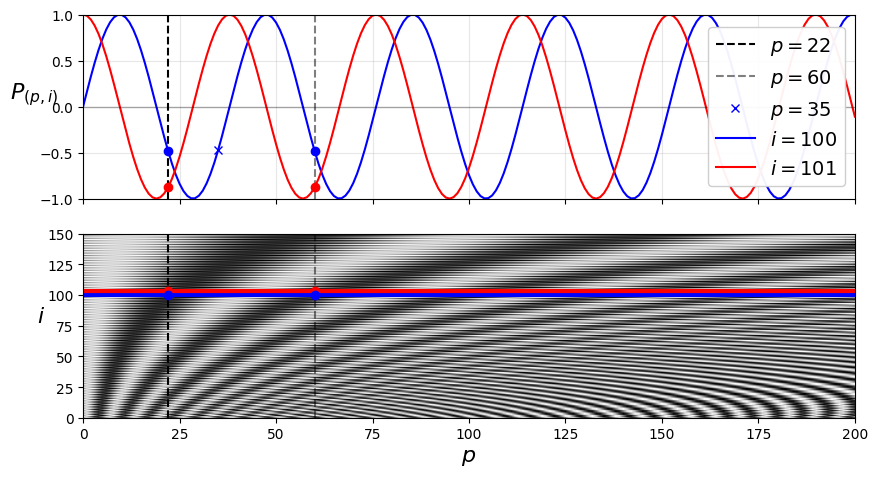

In [69]:
# extra code – this cells generates and saves Figure 16–9
figure_max_length = 201
figure_embed_size = 512
pos_emb = PositionalEncoding(figure_max_length, figure_embed_size)
zeros = np.zeros((1, figure_max_length, figure_embed_size), np.float32)
P = pos_emb(zeros)[0].numpy()
i1, i2, crop_i = 100, 101, 150
p1, p2, p3 = 22, 60, 35
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(9, 5))
ax1.plot([p1, p1], [-1, 1], "k--", label="$p = {}$".format(p1))
ax1.plot([p2, p2], [-1, 1], "k--", label="$p = {}$".format(p2), alpha=0.5)
ax1.plot(p3, P[p3, i1], "bx", label="$p = {}$".format(p3))
ax1.plot(P[:,i1], "b-", label="$i = {}$".format(i1))
ax1.plot(P[:,i2], "r-", label="$i = {}$".format(i2))
ax1.plot([p1, p2], [P[p1, i1], P[p2, i1]], "bo")
ax1.plot([p1, p2], [P[p1, i2], P[p2, i2]], "ro")
ax1.legend(loc="center right", fontsize=14, framealpha=0.95)
ax1.set_ylabel("$P_{(p,i)}$", rotation=0, fontsize=16)
ax1.grid(True, alpha=0.3)
ax1.hlines(0, 0, figure_max_length - 1, color="k", linewidth=1, alpha=0.3)
ax1.axis([0, figure_max_length - 1, -1, 1])
ax2.imshow(P.T[:crop_i], cmap="gray", interpolation="bilinear", aspect="auto")
ax2.hlines(i1, 0, figure_max_length - 1, color="b", linewidth=3)
cheat = 2  # need to raise the red line a bit, or else it hides the blue one
ax2.hlines(i2+cheat, 0, figure_max_length - 1, color="r", linewidth=3)
ax2.plot([p1, p1], [0, crop_i], "k--")
ax2.plot([p2, p2], [0, crop_i], "k--", alpha=0.5)
ax2.plot([p1, p2], [i2+cheat, i2+cheat], "ro")
ax2.plot([p1, p2], [i1, i1], "bo")
ax2.axis([0, figure_max_length - 1, 0, crop_i])
ax2.set_xlabel("$p$", fontsize=16)
ax2.set_ylabel("$i$", rotation=0, fontsize=16)
save_fig("positional_embedding_plot")
plt.show()

### Multi-Head Attention

In [84]:
N = 2  # instead of 6
num_heads = 8
dropout_rate = 0.1
n_units = 128  # for the first Dense layer in each Feed Forward block
encoder_pad_mask = tf.math.not_equal(encoder_input_ids, 0)[:, tf.newaxis]
Z = encoder_in
for _ in range(N):
    skip = Z
    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
    Z = attn_layer(Z, value=Z, attention_mask=encoder_pad_mask)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))
    skip = Z
    Z = tf.keras.layers.Dense(n_units, activation="relu")(Z)
    Z = tf.keras.layers.Dense(embed_size)(Z)
    Z = tf.keras.layers.Dropout(dropout_rate)(Z)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))

In [85]:
decoder_pad_mask = tf.math.not_equal(decoder_input_ids, 0)[:, tf.newaxis]
causal_mask = tf.linalg.band_part(  # creates a lower triangular matrix
    tf.ones((batch_max_len_dec, batch_max_len_dec), tf.bool), -1, 0)

In [86]:
encoder_outputs = Z  # let's save the encoder's final outputs
Z = decoder_in  # the decoder starts with its own inputs
for _ in range(N):
    skip = Z
    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
    Z = attn_layer(Z, value=Z, attention_mask=causal_mask & decoder_pad_mask)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))
    skip = Z
    attn_layer = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_size, dropout=dropout_rate)
    Z = attn_layer(Z, value=encoder_outputs, attention_mask=encoder_pad_mask)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))
    skip = Z
    Z = tf.keras.layers.Dense(n_units, activation="relu")(Z)
    Z = tf.keras.layers.Dense(embed_size)(Z)
    Z = tf.keras.layers.LayerNormalization()(tf.keras.layers.Add()([Z, skip]))

**Warning**: the following cell will take a while to run (possibly 2 or 3 hours if you are not using a GPU).

In [87]:
Y_proba = tf.keras.layers.Dense(vocab_size, activation="softmax")(Z)
model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit((X_train, X_train_dec), Y_train, epochs=10,
          validation_data=((X_valid, X_valid_dec), Y_valid))

Epoch 1/10
3125/3125 [==============================] - 828s 263ms/step - loss: 0.2982 - accuracy: 0.5545 - val_loss: 0.2105 - val_accuracy: 0.6476
Epoch 2/10
3125/3125 [==============================] - 820s 262ms/step - loss: 0.2006 - accuracy: 0.6601 - val_loss: 0.1876 - val_accuracy: 0.6802
Epoch 3/10
3125/3125 [==============================] - 820s 263ms/step - loss: 0.1842 - accuracy: 0.6816 - val_loss: 0.1766 - val_accuracy: 0.6975
Epoch 4/10
3125/3125 [==============================] - 820s 262ms/step - loss: 0.1748 - accuracy: 0.6942 - val_loss: 0.1704 - val_accuracy: 0.7055
Epoch 5/10
3125/3125 [==============================] - 820s 262ms/step - loss: 0.1683 - accuracy: 0.7021 - val_loss: 0.1657 - val_accuracy: 0.7102
Epoch 6/10
3125/3125 [==============================] - 821s 263ms/step - loss: 0.1628 - accuracy: 0.7096 - val_loss: 0.1628 - val_accuracy: 0.7130
Epoch 7/10
3125/3125 [==============================] - 826s 264ms/step - loss: 0.1588 - accuracy: 0.7154 - val_

In [88]:
translate("I like soccer and also going to the beach")

'me gusta el fútbol y yo también voy a la playa'

# HuggingFace

In [89]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")  # many other tasks are available
result = classifier("The actors were very convincing.")

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english)
All model checkpoint layers were used when initializing TFDistilBertForSequenceClassification.

All the layers of TFDistilBertForSequenceClassification were initialized from the model checkpoint at distilbert-base-uncased-finetuned-sst-2-english.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.


Models can be very biased. For example, it may like or dislike some countries depending on the data it was trained on, and how it is used, so use it with care:

In [90]:
classifier(["I am from India.", "I am from Iraq."])

[{'label': 'POSITIVE', 'score': 0.9896161556243896},
 {'label': 'NEGATIVE', 'score': 0.9811071157455444}]

In [91]:
model_name = "huggingface/distilbert-base-uncased-finetuned-mnli"
classifier_mnli = pipeline("text-classification", model=model_name)
classifier_mnli("She loves me. [SEP] She loves me not.")

Some layers from the model checkpoint at huggingface/distilbert-base-uncased-finetuned-mnli were not used when initializing TFDistilBertForSequenceClassification: ['dropout_19']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at huggingface/distilbert-base-uncased-finetuned-mnli and are newly initialized: ['dropout_39']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[{'label': 'contradiction', 'score': 0.9790192246437073}]

In [92]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = TFAutoModelForSequenceClassification.from_pretrained(model_name)

Some layers from the model checkpoint at huggingface/distilbert-base-uncased-finetuned-mnli were not used when initializing TFDistilBertForSequenceClassification: ['dropout_19']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at huggingface/distilbert-base-uncased-finetuned-mnli and are newly initialized: ['dropout_59']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [93]:
token_ids = tokenizer(["I like soccer. [SEP] We all love soccer!",
                       "Joe lived for a very long time. [SEP] Joe is old."],
                      padding=True, return_tensors="tf")
token_ids

{'input_ids': <tf.Tensor: shape=(2, 15), dtype=int32, numpy=
array([[ 101, 1045, 2066, 4715, 1012,  102, 2057, 2035, 2293, 4715,  999,
         102,    0,    0,    0],
       [ 101, 3533, 2973, 2005, 1037, 2200, 2146, 2051, 1012,  102, 3533,
        2003, 2214, 1012,  102]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(2, 15), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int32)>}

In [94]:
token_ids = tokenizer([("I like soccer.", "We all love soccer!"),
                       ("Joe lived for a very long time.", "Joe is old.")],
                      padding=True, return_tensors="tf")
token_ids

{'input_ids': <tf.Tensor: shape=(2, 15), dtype=int32, numpy=
array([[ 101, 1045, 2066, 4715, 1012,  102, 2057, 2035, 2293, 4715,  999,
         102,    0,    0,    0],
       [ 101, 3533, 2973, 2005, 1037, 2200, 2146, 2051, 1012,  102, 3533,
        2003, 2214, 1012,  102]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(2, 15), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int32)>}

In [95]:
outputs = model(token_ids)
outputs

TFSequenceClassifierOutput(loss=None, logits=<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[-2.1123817 ,  1.1786783 ,  1.4101017 ],
       [-0.01478387,  1.0962474 , -0.9919954 ]], dtype=float32)>, hidden_states=None, attentions=None)

In [96]:
Y_probas = tf.keras.activations.softmax(outputs.logits)
Y_probas

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.01619702, 0.43523544, 0.5485676 ],
       [0.22655967, 0.6881726 , 0.0852678 ]], dtype=float32)>

In [97]:
Y_pred = tf.argmax(Y_probas, axis=1)
Y_pred  # 0 = contradiction, 1 = entailment, 2 = neutral

<tf.Tensor: shape=(2,), dtype=int64, numpy=array([2, 1])>

In [98]:
sentences = [("Sky is blue", "Sky is red"), ("I love her", "She loves me")]
X_train = tokenizer(sentences, padding=True, return_tensors="tf").data
y_train = tf.constant([0, 2])  # contradiction, neutral
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(loss=loss, optimizer="nadam", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2)

Epoch 1/2
1/1 [==============================] - 10s 10s/step - loss: 1.1190 - accuracy: 0.5000
Epoch 2/2
1/1 [==============================] - 0s 491ms/step - loss: 0.6666 - accuracy: 0.5000


# Exercise solutions

## 1. to 7.

1. Stateless RNNs can only capture patterns whose length is less than, or equal to, the size of the windows the RNN is trained on. Conversely, stateful RNNs can capture longer-term patterns. However, implementing a stateful RNN is much harder⁠—especially preparing the dataset properly. Moreover, stateful RNNs do not always work better, in part because consecutive batches are not independent and identically distributed (IID). Gradient Descent is not fond of non-IID datasets.
2. In general, if you translate a sentence one word at a time, the result will be terrible. For example, the French sentence "Je vous en prie" means "You are welcome," but if you translate it one word at a time, you get "I you in pray." Huh? It is much better to read the whole sentence first and then translate it. A plain sequence-to-sequence RNN would start translating a sentence immediately after reading the first word, while an Encoder–Decoder RNN will first read the whole sentence and then translate it. That said, one could imagine a plain sequence-to-sequence RNN that would output silence whenever it is unsure about what to say next (just like human translators do when they must translate a live broadcast).
3. Variable-length input sequences can be handled by padding the shorter sequences so that all sequences in a batch have the same length, and using masking to ensure the RNN ignores the padding token. For better performance, you may also want to create batches containing sequences of similar sizes. Ragged tensors can hold sequences of variable lengths, and Keras now supports them, which simplifies handling variable-length input sequences (at the time of this writing, it still does not handle ragged tensors as targets on the GPU, though). Regarding variable-length output sequences, if the length of the output sequence is known in advance (e.g., if you know that it is the same as the input sequence), then you just need to configure the loss function so that it ignores tokens that come after the end of the sequence. Similarly, the code that will use the model should ignore tokens beyond the end of the sequence. But generally the length of the output sequence is not known ahead of time, so the solution is to train the model so that it outputs an end-of-sequence token at the end of each sequence.
4. Beam search is a technique used to improve the performance of a trained Encoder–Decoder model, for example in a neural machine translation system. The algorithm keeps track of a short list of the _k_ most promising output sentences (say, the top three), and at each decoder step it tries to extend them by one word; then it keeps only the _k_ most likely sentences. The parameter _k_ is called the _beam width_: the larger it is, the more CPU and RAM will be used, but also the more accurate the system will be. Instead of greedily choosing the most likely next word at each step to extend a single sentence, this technique allows the system to explore several promising sentences simultaneously. Moreover, this technique lends itself well to parallelization. You can implement beam search by writing a custom memory cell. Alternatively, TensorFlow Addons's seq2seq API provides an implementation.
5. An attention mechanism is a technique initially used in Encoder–Decoder models to give the decoder more direct access to the input sequence, allowing it to deal with longer input sequences. At each decoder time step, the current decoder's state and the full output of the encoder are processed by an alignment model that outputs an alignment score for each input time step. This score indicates which part of the input is most relevant to the current decoder time step. The weighted sum of the encoder output (weighted by their alignment score) is then fed to the decoder, which produces the next decoder state and the output for this time step. The main benefit of using an attention mechanism is the fact that the Encoder–Decoder model can successfully process longer input sequences. Another benefit is that the alignment scores make the model easier to debug and interpret: for example, if the model makes a mistake, you can look at which part of the input it was paying attention to, and this can help diagnose the issue. An attention mechanism is also at the core of the Transformer architecture, in the Multi-Head Attention layers. See the next answer.
6. The most important layer in the Transformer architecture is the Multi-Head Attention layer (the original Transformer architecture contains 18 of them, including 6 Masked Multi-Head Attention layers). It is at the core of language models such as BERT and GPT-2. Its purpose is to allow the model to identify which words are most aligned with each other, and then improve each word's representation using these contextual clues.
7. Sampled softmax is used when training a classification model when there are many classes (e.g., thousands). It computes an approximation of the cross-entropy loss based on the logit predicted by the model for the correct class, and the predicted logits for a sample of incorrect words. This speeds up training considerably compared to computing the softmax over all logits and then estimating the cross-entropy loss. After training, the model can be used normally, using the regular softmax function to compute all the class probabilities based on all the logits.

## 8.
_Exercise:_ Embedded Reber grammars _were used by Hochreiter and Schmidhuber in [their paper](https://homl.info/93) about LSTMs. They are artificial grammars that produce strings such as "BPBTSXXVPSEPE." Check out Jenny Orr's [nice introduction](https://homl.info/108) to this topic. Choose a particular embedded Reber grammar (such as the one represented on Jenny Orr's page), then train an RNN to identify whether a string respects that grammar or not. You will first need to write a function capable of generating a training batch containing about 50% strings that respect the grammar, and 50% that don't._

First we need to build a function that generates strings based on a grammar. The grammar will be represented as a list of possible transitions for each state. A transition specifies the string to output (or a grammar to generate it) and the next state.

In [99]:
default_reber_grammar = [
    [("B", 1)],           # (state 0) =B=>(state 1)
    [("T", 2), ("P", 3)], # (state 1) =T=>(state 2) or =P=>(state 3)
    [("S", 2), ("X", 4)], # (state 2) =S=>(state 2) or =X=>(state 4)
    [("T", 3), ("V", 5)], # and so on...
    [("X", 3), ("S", 6)],
    [("P", 4), ("V", 6)],
    [("E", None)]]        # (state 6) =E=>(terminal state)

embedded_reber_grammar = [
    [("B", 1)],
    [("T", 2), ("P", 3)],
    [(default_reber_grammar, 4)],
    [(default_reber_grammar, 5)],
    [("T", 6)],
    [("P", 6)],
    [("E", None)]]

def generate_string(grammar):
    state = 0
    output = []
    while state is not None:
        index = np.random.randint(len(grammar[state]))
        production, state = grammar[state][index]
        if isinstance(production, list):
            production = generate_string(grammar=production)
        output.append(production)
    return "".join(output)

Let's generate a few strings based on the default Reber grammar:

In [100]:
np.random.seed(42)

for _ in range(25):
    print(generate_string(default_reber_grammar), end=" ")

BTXXTTVPXTVPXTTVPSE BPVPSE BTXSE BPVVE BPVVE BTSXSE BPTVPXTTTVVE BPVVE BTXSE BTXXVPSE BPTTTTTTTTVVE BTXSE BPVPSE BTXSE BPTVPSE BTXXTVPSE BPVVE BPVVE BPVVE BPTTVVE BPVVE BPVVE BTXXVVE BTXXVVE BTXXVPXVVE 

Looks good. Now let's generate a few strings based on the embedded Reber grammar:

In [101]:
np.random.seed(42)

for _ in range(25):
    print(generate_string(embedded_reber_grammar), end=" ")

BTBPTTTVPXTVPXTTVPSETE BPBPTVPSEPE BPBPVVEPE BPBPVPXVVEPE BPBTXXTTTTVVEPE BPBPVPSEPE BPBTXXVPSEPE BPBTSSSSSSSXSEPE BTBPVVETE BPBTXXVVEPE BPBTXXVPSEPE BTBTXXVVETE BPBPVVEPE BPBPVVEPE BPBTSXSEPE BPBPVVEPE BPBPTVPSEPE BPBTXXVVEPE BTBPTVPXVVETE BTBPVVETE BTBTSSSSSSSXXVVETE BPBTSSSXXTTTTVPSEPE BTBPTTVVETE BPBTXXTVVEPE BTBTXSETE 

Okay, now we need a function to generate strings that do not respect the grammar. We could generate a random string, but the task would be a bit too easy, so instead we will generate a string that respects the grammar, and we will corrupt it by changing just one character:

In [102]:
POSSIBLE_CHARS = "BEPSTVX"

def generate_corrupted_string(grammar, chars=POSSIBLE_CHARS):
    good_string = generate_string(grammar)
    index = np.random.randint(len(good_string))
    good_char = good_string[index]
    bad_char = np.random.choice(sorted(set(chars) - set(good_char)))
    return good_string[:index] + bad_char + good_string[index + 1:]

Let's look at a few corrupted strings:

In [103]:
np.random.seed(42)

for _ in range(25):
    print(generate_corrupted_string(embedded_reber_grammar), end=" ")

BTBPTTTPPXTVPXTTVPSETE BPBTXEEPE BPBPTVVVEPE BPBTSSSSXSETE BPTTXSEPE BTBPVPXTTTTTTEVETE BPBTXXSVEPE BSBPTTVPSETE BPBXVVEPE BEBTXSETE BPBPVPSXPE BTBPVVVETE BPBTSXSETE BPBPTTTPTTTTTVPSEPE BTBTXXTTSTVPSETE BBBTXSETE BPBTPXSEPE BPBPVPXTTTTVPXTVPXVPXTTTVVEVE BTBXXXTVPSETE BEBTSSSSSXXVPXTVVETE BTBXTTVVETE BPBTXSTPE BTBTXXTTTVPSBTE BTBTXSETX BTBTSXSSTE 

We cannot feed strings directly to an RNN, so we need to encode them somehow. One option would be to one-hot encode each character. Another option is to use embeddings. Let's go for the second option (but since there are just a handful of characters, one-hot encoding would probably be a good option as well). For embeddings to work, we need to convert each string into a sequence of character IDs. Let's write a function for that, using each character's index in the string of possible characters "BEPSTVX":

In [104]:
def string_to_ids(s, chars=POSSIBLE_CHARS):
    return [chars.index(c) for c in s]

In [105]:
string_to_ids("BTTTXXVVETE")

[0, 4, 4, 4, 6, 6, 5, 5, 1, 4, 1]

We can now generate the dataset, with 50% good strings, and 50% bad strings:

In [106]:
def generate_dataset(size):
    good_strings = [
        string_to_ids(generate_string(embedded_reber_grammar))
        for _ in range(size // 2)
    ]
    bad_strings = [
        string_to_ids(generate_corrupted_string(embedded_reber_grammar))
        for _ in range(size - size // 2)
    ]
    all_strings = good_strings + bad_strings
    X = tf.ragged.constant(all_strings, ragged_rank=1)
    y = np.array([[1.] for _ in range(len(good_strings))] +
                 [[0.] for _ in range(len(bad_strings))])
    return X, y

In [107]:
np.random.seed(42)

X_train, y_train = generate_dataset(10000)
X_valid, y_valid = generate_dataset(2000)

Let's take a look at the first training sequence:

In [108]:
X_train[0]

<tf.Tensor: shape=(22,), dtype=int32, numpy=
array([0, 4, 0, 2, 4, 4, 4, 5, 2, 6, 4, 5, 2, 6, 4, 4, 5, 2, 3, 1, 4, 1],
      dtype=int32)>

What class does it belong to?

In [109]:
y_train[0]

array([1.])

Perfect! We are ready to create the RNN to identify good strings. We build a simple sequence binary classifier:

In [110]:
np.random.seed(42)
tf.random.set_seed(42)

embedding_size = 5

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=[None], dtype=tf.int32, ragged=True),
    tf.keras.layers.Embedding(input_dim=len(POSSIBLE_CHARS),
                              output_dim=embedding_size),
    tf.keras.layers.GRU(30),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02, momentum = 0.95,
                                    nesterov=True)
model.compile(loss="binary_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
313/313 [==============================] - 4s 8ms/step - loss: 0.6910 - accuracy: 0.5095 - val_loss: 0.6825 - val_accuracy: 0.5645
Epoch 2/20
313/313 [==============================] - 2s 7ms/step - loss: 0.6678 - accuracy: 0.5659 - val_loss: 0.6635 - val_accuracy: 0.6105
Epoch 3/20
313/313 [==============================] - 2s 7ms/step - loss: 0.6504 - accuracy: 0.5766 - val_loss: 0.6521 - val_accuracy: 0.6110
Epoch 4/20
313/313 [==============================] - 2s 8ms/step - loss: 0.6347 - accuracy: 0.5980 - val_loss: 0.6224 - val_accuracy: 0.6445
Epoch 5/20
313/313 [==============================] - 2s 7ms/step - loss: 0.6054 - accuracy: 0.6361 - val_loss: 0.5779 - val_accuracy: 0.6980
Epoch 6/20
313/313 [==============================] - 2s 7ms/step - loss: 0.5414 - accuracy: 0.7093 - val_loss: 0.4695 - val_accuracy: 0.7795
Epoch 7/20
313/313 [==============================] - 2s 7ms/step - loss: 0.3756 - accuracy: 0.8418 - val_loss: 0.2685 - val_accuracy: 0.9115
Epoch 

Now let's test our RNN on two tricky strings: the first one is bad while the second one is good. They only differ by the second to last character. If the RNN gets this right, it shows that it managed to notice the pattern that the second letter should always be equal to the second to last letter. That requires a fairly long short-term memory (which is the reason why we used a GRU cell).

In [111]:
test_strings = ["BPBTSSSSSSSXXTTVPXVPXTTTTTVVETE",
                "BPBTSSSSSSSXXTTVPXVPXTTTTTVVEPE"]
X_test = tf.ragged.constant([string_to_ids(s) for s in test_strings], ragged_rank=1)

y_proba = model.predict(X_test)
print()
print("Estimated probability that these are Reber strings:")
for index, string in enumerate(test_strings):
    print("{}: {:.2f}%".format(string, 100 * y_proba[index][0]))


Estimated probability that these are Reber strings:
BPBTSSSSSSSXXTTVPXVPXTTTTTVVETE: 0.02%
BPBTSSSSSSSXXTTVPXVPXTTTTTVVEPE: 99.99%


Ta-da! It worked fine. The RNN found the correct answers with very high confidence. :)

## 9.
_Exercise: Train an Encoder–Decoder model that can convert a date string from one format to another (e.g., from "April 22, 2019" to "2019-04-22")._

Let's start by creating the dataset. We will use random days between 1000-01-01 and 9999-12-31:

In [112]:
from datetime import date

# cannot use strftime()'s %B format since it depends on the locale
MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]

def random_dates(n_dates):
    min_date = date(1000, 1, 1).toordinal()
    max_date = date(9999, 12, 31).toordinal()

    ordinals = np.random.randint(max_date - min_date, size=n_dates) + min_date
    dates = [date.fromordinal(ordinal) for ordinal in ordinals]

    x = [MONTHS[dt.month - 1] + " " + dt.strftime("%d, %Y") for dt in dates]
    y = [dt.isoformat() for dt in dates]
    return x, y

Here are a few random dates, displayed in both the input format and the target format:

In [113]:
np.random.seed(42)

n_dates = 3
x_example, y_example = random_dates(n_dates)
print("{:25s}{:25s}".format("Input", "Target"))
print("-" * 50)
for idx in range(n_dates):
    print("{:25s}{:25s}".format(x_example[idx], y_example[idx]))

Input                    Target                   
--------------------------------------------------
September 20, 7075       7075-09-20               
May 15, 8579             8579-05-15               
January 11, 7103         7103-01-11               


Let's get the list of all possible characters in the inputs:

In [114]:
INPUT_CHARS = "".join(sorted(set("".join(MONTHS) + "0123456789, ")))
INPUT_CHARS

' ,0123456789ADFJMNOSabceghilmnoprstuvy'

And here's the list of possible characters in the outputs:

In [115]:
OUTPUT_CHARS = "0123456789-"

Let's write a function to convert a string to a list of character IDs, as we did in the previous exercise:

In [116]:
def date_str_to_ids(date_str, chars=INPUT_CHARS):
    return [chars.index(c) for c in date_str]

In [117]:
date_str_to_ids(x_example[0], INPUT_CHARS)

[19, 23, 31, 34, 23, 28, 21, 23, 32, 0, 4, 2, 1, 0, 9, 2, 9, 7]

In [118]:
date_str_to_ids(y_example[0], OUTPUT_CHARS)

[7, 0, 7, 5, 10, 0, 9, 10, 2, 0]

In [119]:
def prepare_date_strs(date_strs, chars=INPUT_CHARS):
    X_ids = [date_str_to_ids(dt, chars) for dt in date_strs]
    X = tf.ragged.constant(X_ids, ragged_rank=1)
    return (X + 1).to_tensor() # using 0 as the padding token ID

def create_dataset(n_dates):
    x, y = random_dates(n_dates)
    return prepare_date_strs(x, INPUT_CHARS), prepare_date_strs(y, OUTPUT_CHARS)

In [120]:
np.random.seed(42)

X_train, Y_train = create_dataset(10000)
X_valid, Y_valid = create_dataset(2000)
X_test, Y_test = create_dataset(2000)

In [121]:
Y_train[0]

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 8,  1,  8,  6, 11,  1, 10, 11,  3,  1], dtype=int32)>

### First version: a very basic seq2seq model

Let's first try the simplest possible model: we feed in the input sequence, which first goes through the encoder (an embedding layer followed by a single LSTM layer), which outputs a vector, then it goes through a decoder (a single LSTM layer, followed by a dense output layer), which outputs a sequence of vectors, each representing the estimated probabilities for all possible output character.

Since the decoder expects a sequence as input, we repeat the vector (which is output by the encoder) as many times as the longest possible output sequence.

In [122]:
embedding_size = 32
max_output_length = Y_train.shape[1]

np.random.seed(42)
tf.random.set_seed(42)

encoder = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=len(INPUT_CHARS) + 1,
                           output_dim=embedding_size,
                           input_shape=[None]),
    tf.keras.layers.LSTM(128)
])

decoder = tf.keras.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dense(len(OUTPUT_CHARS) + 1, activation="softmax")
])

model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.RepeatVector(max_output_length),
    decoder
])

optimizer = tf.keras.optimizers.Nadam()
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
313/313 [==============================] - 10s 23ms/step - loss: 1.8150 - accuracy: 0.3489 - val_loss: 1.3726 - val_accuracy: 0.4939
Epoch 2/20
313/313 [==============================] - 7s 22ms/step - loss: 1.2447 - accuracy: 0.5510 - val_loss: 1.0725 - val_accuracy: 0.6115
Epoch 3/20
313/313 [==============================] - 7s 23ms/step - loss: 1.0937 - accuracy: 0.6125 - val_loss: 1.0548 - val_accuracy: 0.6130
Epoch 4/20
313/313 [==============================] - 7s 23ms/step - loss: 1.0032 - accuracy: 0.6413 - val_loss: 3.8747 - val_accuracy: 0.1788
Epoch 5/20
313/313 [==============================] - 8s 26ms/step - loss: 0.8159 - accuracy: 0.7023 - val_loss: 0.6623 - val_accuracy: 0.7474
Epoch 6/20
313/313 [==============================] - 8s 26ms/step - loss: 0.5645 - accuracy: 0.7795 - val_loss: 0.5005 - val_accuracy: 0.8032
Epoch 7/20
313/313 [==============================] - 8s 26ms/step - loss: 0.5037 - accuracy: 0.8103 - val_loss: 0.3798 - val_accuracy: 0.850

Looks great, we reach 100% validation accuracy! Let's use the model to make some predictions. We will need to be able to convert a sequence of character IDs to a readable string:

In [123]:
def ids_to_date_strs(ids, chars=OUTPUT_CHARS):
    return ["".join([("?" + chars)[index] for index in sequence])
            for sequence in ids]

Now we can use the model to convert some dates

In [124]:
X_new = prepare_date_strs(["September 17, 2009", "July 14, 1789"])

In [125]:
ids = model.predict(X_new).argmax(axis=-1)
for date_str in ids_to_date_strs(ids):
    print(date_str)

2009-09-17
1789-07-14


Perfect! :)

However, since the model was only trained on input strings of length 18 (which is the length of the longest date), it does not perform well if we try to use it to make predictions on shorter sequences:

In [126]:
X_new = prepare_date_strs(["May 02, 2020", "July 14, 1789"])

In [127]:
ids = model.predict(X_new).argmax(axis=-1)
for date_str in ids_to_date_strs(ids):
    print(date_str)

2020-02-02
1789-01-14


Oops! We need to ensure that we always pass sequences of the same length as during training, using padding if necessary. Let's write a little helper function for that:

In [128]:
max_input_length = X_train.shape[1]

def prepare_date_strs_padded(date_strs):
    X = prepare_date_strs(date_strs)
    if X.shape[1] < max_input_length:
        X = tf.pad(X, [[0, 0], [0, max_input_length - X.shape[1]]])
    return X

def convert_date_strs(date_strs):
    X = prepare_date_strs_padded(date_strs)
    ids = model.predict(X).argmax(axis=-1)
    return ids_to_date_strs(ids)

In [129]:
convert_date_strs(["May 02, 2020", "July 14, 1789"])

['2020-05-02', '1789-07-14']

Cool! Granted, there are certainly much easier ways to write a date conversion tool (e.g., using regular expressions or even basic string manipulation), but you have to admit that using neural networks is way cooler. ;-)

However, real-life sequence-to-sequence problems will usually be harder, so for the sake of completeness, let's build a more powerful model.

### Second version: feeding the shifted targets to the decoder (teacher forcing)

Instead of feeding the decoder a simple repetition of the encoder's output vector, we can feed it the target sequence, shifted by one time step to the right. This way, at each time step the decoder will know what the previous target character was. This should help is tackle more complex sequence-to-sequence problems.

Since the first output character of each target sequence has no previous character, we will need a new token to represent the start-of-sequence (sos).

During inference, we won't know the target, so what will we feed the decoder? We can just predict one character at a time, starting with an sos token, then feeding the decoder all the characters that were predicted so far (we will look at this in more details later in this notebook).

But if the decoder's LSTM expects to get the previous target as input at each step, how shall we pass it it the vector output by the encoder? Well, one option is to ignore the output vector, and instead use the encoder's LSTM state as the initial state of the decoder's LSTM (which requires that encoder's LSTM must have the same number of units as the decoder's LSTM).

Now let's create the decoder's inputs (for training, validation and testing). The sos token will be represented using the last possible output character's ID + 1.

In [130]:
sos_id = len(OUTPUT_CHARS) + 1

def shifted_output_sequences(Y):
    sos_tokens = tf.fill(dims=(len(Y), 1), value=sos_id)
    return tf.concat([sos_tokens, Y[:, :-1]], axis=1)

X_train_decoder = shifted_output_sequences(Y_train)
X_valid_decoder = shifted_output_sequences(Y_valid)
X_test_decoder = shifted_output_sequences(Y_test)

Let's take a look at the decoder's training inputs:

In [131]:
X_train_decoder

<tf.Tensor: shape=(10000, 10), dtype=int32, numpy=
array([[12,  8,  1, ..., 10, 11,  3],
       [12,  9,  6, ...,  6, 11,  2],
       [12,  8,  2, ...,  2, 11,  2],
       ...,
       [12, 10,  8, ...,  2, 11,  4],
       [12,  2,  2, ...,  3, 11,  3],
       [12,  8,  9, ...,  8, 11,  3]], dtype=int32)>

Now let's build the model. It's not a simple sequential model anymore, so let's use the functional API:

In [132]:
encoder_embedding_size = 32
decoder_embedding_size = 32
lstm_units = 128

np.random.seed(42)
tf.random.set_seed(42)

encoder_input = tf.keras.layers.Input(shape=[None], dtype=tf.int32)
encoder_embedding = tf.keras.layers.Embedding(
    input_dim=len(INPUT_CHARS) + 1,
    output_dim=encoder_embedding_size)(encoder_input)
_, encoder_state_h, encoder_state_c = tf.keras.layers.LSTM(
    lstm_units, return_state=True)(encoder_embedding)
encoder_state = [encoder_state_h, encoder_state_c]

decoder_input = tf.keras.layers.Input(shape=[None], dtype=tf.int32)
decoder_embedding = tf.keras.layers.Embedding(
    input_dim=len(OUTPUT_CHARS) + 2,
    output_dim=decoder_embedding_size)(decoder_input)
decoder_lstm_output = tf.keras.layers.LSTM(lstm_units, return_sequences=True)(
    decoder_embedding, initial_state=encoder_state)
decoder_output = tf.keras.layers.Dense(len(OUTPUT_CHARS) + 1,
                                    activation="softmax")(decoder_lstm_output)

model = tf.keras.Model(inputs=[encoder_input, decoder_input],
                           outputs=[decoder_output])

optimizer = tf.keras.optimizers.Nadam()
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit([X_train, X_train_decoder], Y_train, epochs=10,
                    validation_data=([X_valid, X_valid_decoder], Y_valid))

Epoch 1/10
313/313 [==============================] - 11s 27ms/step - loss: 1.6824 - accuracy: 0.3734 - val_loss: 1.4054 - val_accuracy: 0.4681
Epoch 2/10
313/313 [==============================] - 8s 26ms/step - loss: 1.1935 - accuracy: 0.5550 - val_loss: 0.8868 - val_accuracy: 0.6750
Epoch 3/10
313/313 [==============================] - 8s 26ms/step - loss: 0.6403 - accuracy: 0.7700 - val_loss: 0.3493 - val_accuracy: 0.8978
Epoch 4/10
313/313 [==============================] - 8s 26ms/step - loss: 0.2292 - accuracy: 0.9423 - val_loss: 0.1254 - val_accuracy: 0.9782
Epoch 5/10
313/313 [==============================] - 8s 26ms/step - loss: 0.0694 - accuracy: 0.9932 - val_loss: 0.0441 - val_accuracy: 0.9982
Epoch 6/10
313/313 [==============================] - 9s 29ms/step - loss: 0.0576 - accuracy: 0.9923 - val_loss: 0.0280 - val_accuracy: 0.9988
Epoch 7/10
313/313 [==============================] - 8s 26ms/step - loss: 0.0179 - accuracy: 0.9998 - val_loss: 0.0143 - val_accuracy: 0.999

This model also reaches 100% validation accuracy, but it does so even faster.

Let's once again use the model to make some predictions. This time we need to predict characters one by one.

In [133]:
sos_id = len(OUTPUT_CHARS) + 1

def predict_date_strs(date_strs):
    X = prepare_date_strs_padded(date_strs)
    Y_pred = tf.fill(dims=(len(X), 1), value=sos_id)
    for index in range(max_output_length):
        pad_size = max_output_length - Y_pred.shape[1]
        X_decoder = tf.pad(Y_pred, [[0, 0], [0, pad_size]])
        Y_probas_next = model.predict([X, X_decoder])[:, index:index+1]
        Y_pred_next = tf.argmax(Y_probas_next, axis=-1, output_type=tf.int32)
        Y_pred = tf.concat([Y_pred, Y_pred_next], axis=1)
    return ids_to_date_strs(Y_pred[:, 1:])

In [134]:
predict_date_strs(["July 14, 1789", "May 01, 2020"])

['1789-07-14', '2020-05-01']

Works fine! Next, feel free to write a Transformer version. :)

## 10.
_Exercise: Go through Keras's tutorial for [Natural language image search with a Dual Encoder](https://homl.info/dualtuto). You will learn how to build a model capable of representing both images and text within the same embedding space. This makes it possible to search for images using a text prompt, like in the [CLIP model](https://openai.com/blog/clip/) by OpenAI._ 

Just click the link and follow the instructions.

## 11.
_Exercise: Use the Transformers library to download a pretrained language model capable of generating text (e.g., GPT), and try generating more convincing Shakespearean text. You will need to use the model's `generate()` method—see Hugging Face's documentation for more details._

First, let's load a pretrained model. In this example, we will use OpenAI's GPT model, with an additional Language Model on top (just a linear layer with weights tied to the input embeddings). Let's import it and load the pretrained weights (this will download about 445MB of data to `~/.cache/torch/transformers`):

In [135]:
from transformers import TFOpenAIGPTLMHeadModel

model = TFOpenAIGPTLMHeadModel.from_pretrained("openai-gpt")

All model checkpoint layers were used when initializing TFOpenAIGPTLMHeadModel.

All the layers of TFOpenAIGPTLMHeadModel were initialized from the model checkpoint at openai-gpt.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFOpenAIGPTLMHeadModel for predictions without further training.


Next we will need a specialized tokenizer for this model. This one will try to use the [spaCy](https://spacy.io/) and [ftfy](https://pypi.org/project/ftfy/) libraries if they are installed, or else it will fall back to BERT's `BasicTokenizer` followed by Byte-Pair Encoding (which should be fine for most use cases).

In [136]:
from transformers import OpenAIGPTTokenizer

tokenizer = OpenAIGPTTokenizer.from_pretrained("openai-gpt")

ftfy or spacy is not installed using BERT BasicTokenizer instead of SpaCy & ftfy.


Now let's use the tokenizer to tokenize and encode the prompt text:

In [137]:
tokenizer("hello everyone")

{'input_ids': [3570, 1473], 'attention_mask': [1, 1]}

In [138]:
prompt_text = "This royal throne of kings, this sceptred isle"
encoded_prompt = tokenizer.encode(prompt_text,
                                  add_special_tokens=False,
                                  return_tensors="tf")
encoded_prompt

<tf.Tensor: shape=(1, 10), dtype=int32, numpy=
array([[  616,  5751,  6404,   498,  9606,   240,   616, 26271,  7428,
        16187]], dtype=int32)>

Easy! Next, let's use the model to generate text after the prompt. We will generate 5 different sentences, each starting with the prompt text, followed by 40 additional tokens. For an explanation of what all the hyperparameters do, make sure to check out this great [blog post](https://huggingface.co/blog/how-to-generate) by Patrick von Platen (from Hugging Face). You can play around with the hyperparameters to try to obtain better results.

In [139]:
num_sequences = 5
length = 40

generated_sequences = model.generate(
    input_ids=encoded_prompt,
    do_sample=True,
    max_length=length + len(encoded_prompt[0]),
    temperature=1.0,
    top_k=0,
    top_p=0.9,
    repetition_penalty=1.0,
    num_return_sequences=num_sequences,
)

generated_sequences

<tf.Tensor: shape=(5, 50), dtype=int32, numpy=
array([[  616,  5751,  6404,   498,  9606,   240,   616, 26271,  7428,
        16187,   498,   481,   550, 12974,   554, 20275,   544,   481,
          808,  1082,   525,   759, 13717,   507,   617,   616,  1294,
         1276,   239, 40477,   249,  1048,  2210,   525,   249,   880,
          694,   817,   485,   788,   507,   240,   244,   481,   762,
         4049,  3983,  6474,  1387,   485],
       [  616,  5751,  6404,   498,  9606,   240,   616, 26271,  7428,
        16187,   509,  1163,   485,  1272,  8660,  3380, 14760,   240,
         1389,   557,   481,  7232,     8,   789,  3408,   239,   754,
        10253,   558,   694,  2556,   488,  2093,   485,  2185,   917,
           11,  5272,  6372,   562,  1272, 11413,   239, 40477,   481,
         1583,   618,   558,   524,  1074],
       [  616,  5751,  6404,   498,  9606,   240,   616, 26271,  7428,
        16187,   544,   597,   622,  1163,   488,   481,  1594,   498,
          622

Now let's decode the generated sequences and print them:

In [140]:
for sequence in generated_sequences:
    text = tokenizer.decode(sequence, clean_up_tokenization_spaces=True)
    print(text)
    print("-" * 80)

this royal throne of kings, this sceptred isle of the necronomicon is the only place that can unlock it from this dark world. 
 i am surprised that i've been able to see it, " the man named dallon says to
--------------------------------------------------------------------------------
this royal throne of kings, this sceptred isle was home to many beloved possessors, such as the mighty astaroth. their wives had been husband and wife to lord teixiara for many generations. 
 the high king had his own
--------------------------------------------------------------------------------
this royal throne of kings, this sceptred isle is now our home and the land of our fathers!'this was made the standard of the coates, which is at king celebrant's command. 
 this was the longest story the coates
--------------------------------------------------------------------------------
this royal throne of kings, this sceptred isle has a powerful spirit that can not be severed or erased. it will reign unti

You can try more recent (and larger) models, such as GPT-2, CTRL, Transformer-XL or XLNet, which are all available as pretrained models in the transformers library, including variants with Language Models on top. The preprocessing steps vary slightly between models, so make sure to check out this [generation example](https://github.com/huggingface/transformers/blob/master/examples/run_generation.py) from the transformers documentation (this example uses PyTorch, but it will work with very little tweaks, such as adding `TF` at the beginning of the model class name, removing the `.to()` method calls, and using `return_tensors="tf"` instead of `"pt"`.

Hope you enjoyed this chapter! :)